In [637]:
import numpy as np
import sympy
from sympy import symbols, Eq, linear_eq_to_matrix
import random
import matplotlib.pyplot as plt
from collections import deque, defaultdict
# from pyeda.inter import expr, exprvar, expr2bdd
# from dd.autoref import BDD
import networkx as nx
from matplotlib.colors import ListedColormap
import itertools
import pandas as pd
from sympy.logic.boolalg import SOPform
import re
import pickle
import datetime
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from itertools import product
import seaborn as sns
from collections import deque


# change the code to save the data in sqlite database or pickle file to store the results
    # store number of devices in each path
    # Store currents in each path for future plots

#make code run in hipergator

#run upto 3-bit adder for optimal solution with 10 iterations and generate graphs

#############################################################################

#find and pinpoint cases that get only max zeros and min ones current

# 1 - (number of devices)
# 0 - (neighbour lrs devices to ground)
# run the simulation for only those special cases
import sys
import os
import importlib

In [638]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

In [816]:
# Insert the parent directory (one level up) into sys.path:
parent_dir = os.path.abspath("..")  # or an explicit path to the parent
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# First import the module in a normal way:
import PathDesignGeneration

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignGeneration)
from PathDesignGeneration import PATH

# fails = ['apex4'] #revlib
# benchmark_lst = ["in0", "apex2", "misex3", "pdc", "seq", "spla", "tial", "cps", "apex5", "bw", "frg1"]  #revlib
# benchmark_lst = ["in0"]  #revlib
# directory = 'revlib'

# benchmark_lst = ["c17"]  #iscas85
# directory = 'iscas85'

# filename_lst = {benchmark:f"../bdds/benchmarks/{directory}/"+benchmark_lst[i]+".sbdd" for i, benchmark in enumerate(benchmark_lst)}

benchmark_lst = ['3-bitAdder']
filename_lst = {str(i)+"-bitAdder":"../bdds/"+str(i)+"-bitAdder.sbdd" for i in range(1, 18+1)}

Functional_Logic_Of_Path_Crossbar_Programings = {}
for benchmark in benchmark_lst:
    start_time = time.time()
    # filename = filename_lst[str(adderbit)+'-bitAdder']
    filename = filename_lst[benchmark]

    # if(adderbit<10):
    #     outputs, df = truth_tables_data[str(adderbit)+'-bitAdder']["outputs"], truth_tables_data[str(adderbit)+'-bitAdder']["TruthTable_df"]
    # else:
    #     outputs, df = None, None
        
    path = PATH(CrossbarGridSize = 100)
    # path.TruthTable_to_BooleanExpression(df, outputs=outputs)
    # path.BooleanExpresions_to_BDD()
    # print("----------------------------------------------------------------------------------------------")
    # expressions = {'F0' : '(a & b) | (a & cin) | (b & cin)',
    # 'F1' : '(a & b & cin) | (a & ~b & ~cin) | (b & ~a & ~cin) | (cin & ~a & ~b)'}
    # variables = ['a', 'b', 'cin']
    # path.SetBooleanExpressionsAndVaribles(variables = variables, expressions = expressions, outputs = list(expressions.keys()))
    # print("----------------------------------------------------------------------------------------------")
    
    # path.SetBooleanExpressionsAndVaribles(variables = None, expressions = None, outputs = outputs, OriginalTruthTable=df)
    path.parse_file_to_NetworkXGraph(filename)
    path.BDD_to_NetworkXGraph()
    # if(adderbit<5):
    #     path.Verify_BDD_to_NetworkXGraph(withExpression=False, withOriginalTruthTable=False, generateFromBDD=True)
    # path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphPreprocessing()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph()
    # print("----------------------------------------------------------------------------------------------")
    path.GraphTransformation()
    # path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")
    path.GraphCompression()
    # if(adderbit==1):
    #     path.VisuvaliseNetworkXGraph(bipartite=True)
    # print("----------------------------------------------------------------------------------------------")

    path.GraphSplittingWithHeightConstraint(height=10)

    path.GraphSplittinWithSizeConstraint(size=64)
    
    path.CrossbarDesignRelalization()

    # path.InferPrerequisiteTrees()

    # print('path.Processed_graphs_Map', path.Processed_graphs_Map.keys())

    # print('path.Processed_graphs_Map[None]',path.Processed_graphs_Map[None])

    # print('path.output_node_index',path.output_node_index)

    # rows, cols, count = 0, 0, 0
    # dimMap = {}
    # for key in path.Processed_graphs_Map:
    #     row = len(path.Processed_graphs_Map[key]['Crossbar_design'])
    #     col = len(path.Processed_graphs_Map[key]['Crossbar_design'][0])

    #     if(f'{row}x{col}' not in dimMap):
    #         dimMap[f'{row}x{col}'] = 0
    #     dimMap[f'{row}x{col}']+=1
    #     rows+=row
    #     cols+=col
    #     count+=1

    # print('Total = rows x cols:', rows,"x", cols, "count:", count)
    # print(dimMap)

    # Functional_Logic_Of_Path_Crossbar_Programings[str(adderbit)+'-bitAdder'] = {'Crossbar':path.CrossbarResistiveStates, 'Bitlines':path.Bitlines, 'TruthTable':path.OriginalTruthTable, 'OutputLine_Map':path.OutputLine_Map, 'AdderBit':str(adderbit)+'-bitAdder', 'SBDD (V x E)':path.SBDD_dimentions}
    
    print(f"{benchmark} took {time.time() - start_time:.6f} seconds")

    # print('path.CrossbarLongPaths',path.CrossbarLongPaths)
    print("_________________________________________________________________________")
    # if(benchmark==benchmark):
    #     break

# Save (pickle) to a file
# with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "wb") as f:
#     pickle.dump(Functional_Logic_Of_Path_Crossbar_Programings, f)
# print("Data saved to multi_data.pkl")

longPath ['1', '~cin', '7', '~b0', '14', 'a0', '12', '~b1', '21', 'a1', '27', 'O0']
longPath ['11', 'b2', '18', 'a2', '26', 'O5']
longPath ['2', 'a2', '9', 'O6']
longPath ['10', '~b2', '18', 'a2', '26', 'O5']
3-bitAdder took 0.004000 seconds
_________________________________________________________________________


O2 out_split_id 48310bc5-1c08-4ec3-ae3d-6d8bccedc761
O3 out_split_id dfdd9c59-0faf-4b06-9ce8-b511da680812
O4 out_split_id 37d4b3a5-c0df-4dff-9653-76347172c4ea


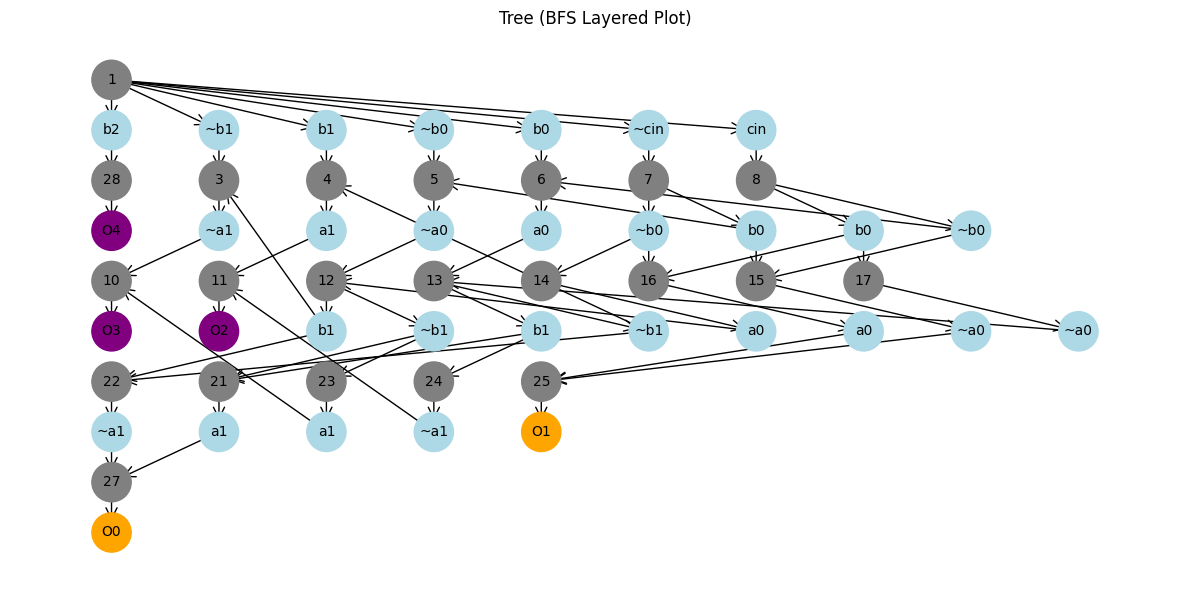

2 in_split_ids {'37d4b3a5-c0df-4dff-9653-76347172c4ea'}
10 in_split_ids {'dfdd9c59-0faf-4b06-9ce8-b511da680812'}
11 in_split_ids {'48310bc5-1c08-4ec3-ae3d-6d8bccedc761'}


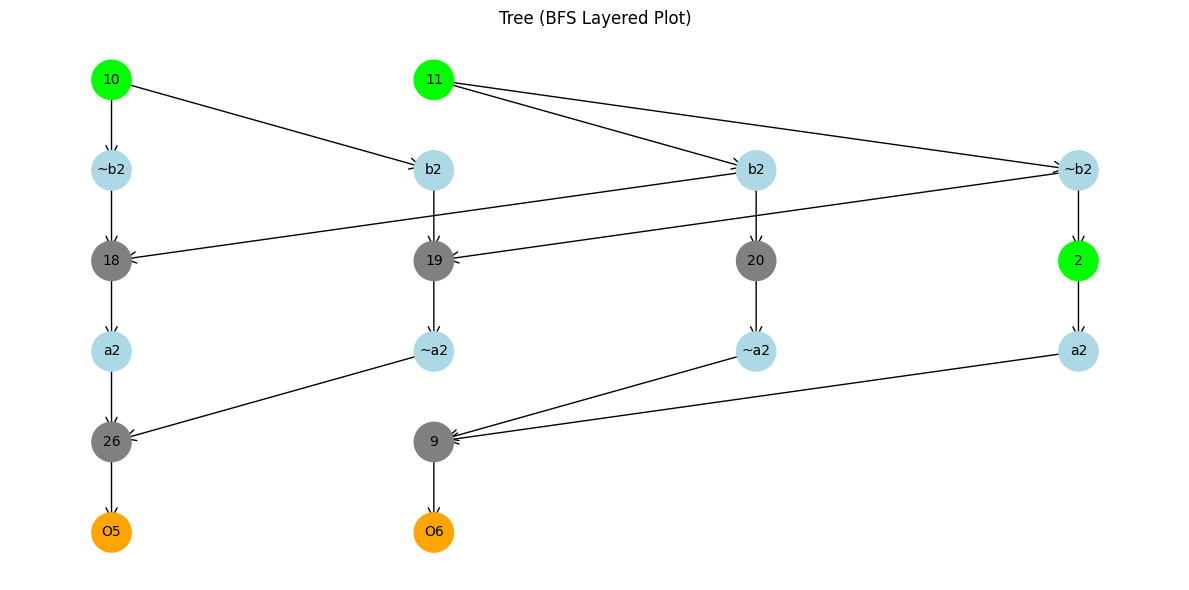

In [817]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, deque

def plot_tree_bfs_layered(G, node_labels=True, edge_labels=False, title="Tree (BFS Layered Plot)", debug=False):
    # Step 1: Find the root node (U1 node with no predecessors)
    # Step 1: Find all root nodes (U1 nodes with no predecessors)
    roots = [
        node for node in G.nodes
        if G.nodes[node].get("BipartitePart") == "U1" and G.in_degree(node) == 0
    ]
    if not roots:
        raise ValueError("No root nodes found (U1 nodes with no predecessors)")

    # Step 2: BFS from all roots to assign levels
    levels = {root: 0 for root in roots}
    layer_nodes = defaultdict(list)
    queue = deque(roots)

    for root in roots:
        layer_nodes[0].append(root)

    while queue:
        node = queue.popleft()
        level = levels[node]

        for succ in G.successors(node):
            if succ not in levels:
                levels[succ] = level + 1
                layer_nodes[level + 1].append(succ)
                queue.append(succ)

    # Step 3: Assign positions
    pos = {}
    x_gap = 2.5
    y_gap = 1.5
    for level, nodes in layer_nodes.items():
        for i, node in enumerate(nodes):
            pos[node] = (i * x_gap, -level * y_gap)

    # Step 4: Assign positions to unplaced nodes (unreachable from root)
    unplaced_nodes = [node for node in G.nodes if node not in pos]
    if unplaced_nodes:
        extra_level = max(layer_nodes.keys(), default=0) + 1
        for i, node in enumerate(unplaced_nodes):
            pos[node] = (i * x_gap, -extra_level * y_gap)

    # Step 5: Determine node colors
    node_colors = []
    for node in G.nodes:
        if node in unplaced_nodes:
            node_colors.append('red')
        else:
            literal = G.nodes[node].get('literal', '')
            in_split_ids = G.nodes[node].get('in_split_id',set())
            out_split_id = G.nodes[node].get('out_split_id',None)
            if(in_split_ids != set()):
                if(debug):
                    print(literal, 'in_split_ids',in_split_ids)
            if(out_split_id != None):
                if(debug):
                    print(literal, 'out_split_id',out_split_id)
            if out_split_id != None:
                node_colors.append('purple')
            elif len(in_split_ids)>0:
                node_colors.append('lime')
            elif 'O' in literal:
                node_colors.append('orange')
            elif literal.isdigit():
                node_colors.append('grey')
            else:
                node_colors.append('lightblue')

    # Step 6: Draw the graph
    plt.figure(figsize=(12, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=20)

    if node_labels:
        labels = {n: G.nodes[n].get('literal', str(n)) for n in G.nodes}
        nx.draw_networkx_labels(G, pos, labels, font_size=10)

    if edge_labels:
        edge_lbls = {(u, v): d.get('condition', '') for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_lbls, font_size=8)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

for i,key in enumerate(path.Processed_group_graphs_Map):
    # if(i not in [2,4,5,7,9,10,11,12]):
    #     continue
    # for row in path.Processed_graphs_Map[key]['Crossbar_design']:
    #     print(row)
    # print(path.Processed_graphs_Map[key]['Selector_Lines_Map'])
    # print(key, i)
    # print(path.Processed_group_graphs_Map[key]['OutputLine_group_Map'])
    # print(key)
    if(i>2):
        continue
    plot_tree_bfs_layered(
        path.Processed_group_graphs_Map[key]['processed_group_graph'],
        debug=True
    )

In [818]:
len(path.Processed_group_graphs_Map)

2

In [672]:
# First import the module in a normal way:
import PathDesignLogicalVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignLogicalVerification)
from PathDesignLogicalVerification import PATH_Design_Logic_Verification, Bus

# for node in path.Processed_group_graphs_Map:
#     # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
#     #     print(row)
#     # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
#     # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
#     # print()
#     # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
#     # print(path.Processed_graphs_Map[node]['LongestPath'])
#     # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
#     # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
#     print('------------------------------------------------')

CrossbarGridSize = 128

bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)



total_rows = 0
total_cols = 0
Processed_group_graphs_Map = {}
for design_ID in path.Processed_group_graphs_Map:
    m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
    n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
    if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
        Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
        total_rows += m
        total_cols += n
    else:
        path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
        Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
if(len(Processed_group_graphs_Map)):
    path_functional_verification = PATH_Design_Logic_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

print('NumberOfDesigns:', bus.getNumberOfDesigns())
print('NumberOfCrossbars:', bus.getNumberOfCrossbars())

test_results = bus.RunRandomTestCases(num_tests=10, RunAllTests=False)
# print()
# test_results = bus.RunRandomTestCasesOnEachDesign(1)

# OutputLine_group_selectorLines_Map
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# GoldenModelOutputMap['f63']

NumberOfDesigns: 2
NumberOfCrossbars: 1
______________________________________
[✅] Test 1 Passed {'cout': 0, 'sum2': 1, 'sum1': 0, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 2 Passed {'cout': 1, 'sum2': 1, 'sum1': 1, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 3 Passed {'cout': 1, 'sum2': 0, 'sum1': 1, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 4 Passed {'cout': 1, 'sum2': 0, 'sum1': 0, 'sum0': 0}
______________________________________
______________________________________
[✅] Test 5 Passed {'cout': 0, 'sum2': 1, 'sum1': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 6 Passed {'cout': 1, 'sum2': 0, 'sum1': 0, 'sum0': 1}
______________________________________
______________________________________
[✅] Test 7 Passed {'cout': 0, 'sum2': 0, 'sum1': 1, 'sum0': 1}
____________

In [659]:
failed_cases = []
n = len(test_results)

for i in range(n):
    model_output = test_results[i]['model_output']
    golden_output = test_results[i]['golden_output']
    if(golden_output!=model_output):
        failed_cases.append(test_results[i])

print(len(failed_cases))
#f6 f10

0


In [660]:
falsePositive = 0
for failed_case in failed_cases:
    OutputMap = failed_case['model_output']
    GoldenModelOutputMap = failed_case['golden_output']
    flag=True
    for key in OutputMap:
        if(OutputMap[key]!=GoldenModelOutputMap[key]):
            if(OutputMap[key]==1 and flag):
                falsePositive+=1
                flag=False
            # print(f'missmatch at {key}')
            # print(f'OutputMap[key]!=GoldenModelOutputMap[key]')
            # print(f'{OutputMap[key]}!={GoldenModelOutputMap[key]}')
falsePositive

0

In [661]:
# outputOfTree, results = bus.RunTestCasesOnDesignTrees({'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1})

# for design_ID_group in results:
#     output_map = results[design_ID_group][0]
#     path_map = results[design_ID_group][1]
#     intersectionToNodeId = results[design_ID_group][2]
#     if('f58' in output_map and output_map['f58']):
#         endPath = path_map['f58']
#         endPath_design_ID_group = design_ID_group
#         break
# # print('outputOfTree', outputOfTree)
# endPath

In [662]:
# bus.crossbar_designs[endPath_design_ID_group]['processed_group_graph'].nodes['16956']
# bus.crossbar_designs[endPath_design_ID_group]['processed_group_graph'].nodes['EdgeNode_1726']

In [663]:
# def findEndNode(endPath_temp):
#     for design_ID_group in results:
#         intersectionToNodeId = results[design_ID_group][2]
    
#         start_endNode = endPath_temp[0]
#         for splitIDSet, WordLineNodeID in intersectionToNodeId.items():
#             if(WordLineNodeID == start_endNode):
#                 InSplitIDs = splitIDSet
                
#                 return InSplitIDs

# def findGraphWithOutSplitID(findingOutSplitIDs):
#     graphandOutputNode = []
#     for design_ID in path.Processed_group_graphs_Map:
#         processed_group_graph = path.Processed_group_graphs_Map[design_ID]['processed_group_graph']
#         for node in processed_group_graph.nodes:
#             if(processed_group_graph.nodes[node]['out_split_id'] in findingOutSplitIDs):
#                 literal = processed_group_graph.nodes[node]['literal']
#                 out_split_id = processed_group_graph.nodes[node]['out_split_id']
#                 graphandOutputNode.append((design_ID, processed_group_graph, node, literal, out_split_id))
#     return graphandOutputNode

# def findIntermediatePath(graphandOutputNode):
#     design_ID_group_curr = graphandOutputNode[0]
#     graph = graphandOutputNode[1]
#     nodeID = graphandOutputNode[2]
#     literal = graphandOutputNode[3]
#     out_split_id = graphandOutputNode[4]

#     path_map = results[design_ID_group_curr][1]

#     print(graph.nodes['1467_ID'])
#     print(graph.nodes['EdgeNode_2722'])
    
#     return path_map[out_split_id]
    
# print(endPath)
# InSplitIDs = findEndNode(endPath)
# # print('InSplitIDs',InSplitIDs)
# graphandOutputNode = findGraphWithOutSplitID(InSplitIDs)
# findIntermediatePath(graphandOutputNode[0])

In [664]:
# nodesPath = ['7397', 'EdgeNode_2387', '10114', 'EdgeNode_2355', '19527', 'EdgeNode_2214']
# for node in nodesPath:
#     print(bus.MainBDD_For_GoldenModel.nodes[node]['literal'])

In [665]:
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# GoldenModelOutputMap['f58']

In [666]:
# input_assignment['x1']

In [667]:
# input_assignment = {'x0': 0, 'x1': 0, 'x10': 1, 'x100': 0, 'x101': 0, 'x102': 1, 'x103': 0, 'x104': 0, 'x105': 0, 'x106': 1, 'x107': 1, 'x108': 0, 'x109': 0, 'x11': 1, 'x110': 1, 'x111': 0, 'x112': 0, 'x113': 1, 'x114': 0, 'x115': 1, 'x116': 1, 'x12': 1, 'x13': 1, 'x14': 0, 'x15': 0, 'x16': 1, 'x17': 0, 'x18': 0, 'x19': 1, 'x20': 0, 'x21': 1, 'x22': 0, 'x23': 1, 'x24': 1, 'x25': 0, 'x26': 1, 'x27': 1, 'x28': 1, 'x29': 1, 'x3': 1, 'x30': 1, 'x31': 0, 'x32': 0, 'x33': 0, 'x34': 0, 'x35': 0, 'x36': 0, 'x37': 0, 'x38': 1, 'x39': 1, 'x4': 1, 'x40': 1, 'x41': 0, 'x42': 0, 'x43': 1, 'x44': 0, 'x45': 1, 'x46': 0, 'x47': 1, 'x48': 0, 'x49': 0, 'x5': 1, 'x50': 0, 'x51': 0, 'x52': 1, 'x53': 0, 'x54': 0, 'x55': 0, 'x56': 0, 'x57': 0, 'x58': 0, 'x6': 0, 'x61': 1, 'x62': 0, 'x63': 1, 'x64': 0, 'x65': 0, 'x66': 0, 'x67': 0, 'x68': 0, 'x69': 1, 'x7': 1, 'x70': 1, 'x71': 1, 'x72': 0, 'x73': 1, 'x74': 1, 'x75': 0, 'x76': 0, 'x77': 0, 'x78': 1, 'x79': 0, 'x8': 1, 'x80': 0, 'x81': 0, 'x82': 0, 'x83': 0, 'x84': 0, 'x85': 1, 'x86': 0, 'x87': 1, 'x88': 1, 'x89': 0, 'x9': 1, 'x90': 0, 'x91': 0, 'x92': 1, 'x93': 1, 'x94': 1, 'x95': 0, 'x96': 0, 'x97': 0, 'x98': 0, 'x99': 1}
# OutputMap = bus.ExecuteDesignsInTopologicalOrder(input_assignment)
# print(OutputMap)
# print()
# GoldenModelOutputMap, pathsMap = bus.GoldenModel(input_assignment)
# print(GoldenModelOutputMap)
# print()
# for key in OutputMap:
#     if(OutputMap[key]!=GoldenModelOutputMap[key]):
#         print(f'missmatch at {key}')
#         print(f'OutputMap[key]!=GoldenModelOutputMap[key]')
#         print(f'{OutputMap[key]}!={GoldenModelOutputMap[key]}')

In [668]:
# [bus.MainBDD_For_GoldenModel.nodes[node]['literal'] for node in pathsMap['f67']]

In [669]:
# bus.MainBDD_For_GoldenModel.nodes[pathsMap['f58'][4]]

In [670]:
def binary_dict_to_str(d, prefix, length):
    """Extract bits with a given prefix and return as a binary string (MSB to LSB)."""
    return ''.join(str(d[f"{prefix}{i}"]) for i in reversed(range(length)))

def run_adder_tests(test_results):
    for test in test_results:
        input_data = test['input']
        
        # Determine the bit width (e.g., a0–a4 → 5 bits)
        a_keys = [k for k in input_data if k.startswith("a")]
        b_keys = [k for k in input_data if k.startswith("b")]
        bit_width = max(int(k[1:]) for k in a_keys + b_keys) + 1
        
        a_bin = binary_dict_to_str(input_data, 'a', bit_width)
        b_bin = binary_dict_to_str(input_data, 'b', bit_width)
        cin_bin = str(input_data['cin'])

        # Run adder
        total = int(a_bin, 2) + int(b_bin, 2) + int(cin_bin, 2)
        sum_bin = bin(total)[2:].zfill(bit_width + 1)  # +1 for possible carry out

        # Extract sum and cout from result
        sum_bits = list(reversed(sum_bin[-bit_width:]))  # sum0 = LSB
        cout = int(sum_bin[:-bit_width] or '0')

        # Format result to compare with golden_output
        computed_output = {f"sum{i}": int(bit) for i, bit in enumerate(sum_bits)}
        computed_output["cout"] = cout

        match = computed_output == test['golden_output']
        
        print(f"Test {test['test_id']}:", "✅ Match" if match else "❌ Mismatch")
        if not match:
            print(f"  Input:      a={a_bin}, b={b_bin}, cin={cin_bin}")
            print(f"  Computed:   {computed_output}")
            print(f"  Expected:   {test['golden_output']}")
            print()
            
# run_adder_tests(test_results)

In [1044]:
# First import the module in a normal way:
import PathDesignAnalogVerification

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(PathDesignAnalogVerification)
from PathDesignAnalogVerification import PATH_Design_Analog_Verification, Bus

# for node in path.Processed_group_graphs_Map:
#     # for row in path.Processed_graphs_Map[node]['Crossbar_design']:
#     #     print(row)
#     # print(path.Processed_graphs_Map[node]['Selector_Lines_Map'])
#     # print(path.Processed_graphs_Map[node]['OutputLine_Map'])
#     # print()
#     # print(path.Processed_graphs_Map[node]['BDD_dimentions'])
#     # print(path.Processed_graphs_Map[node]['LongestPath'])
#     # print(path.Processed_graphs_Map[node]['DesignIdItemToWordLineInputMap'])
#     # print(path.Processed_graphs_Map[node]['PrerequisiteTrees'])
#     print('------------------------------------------------')

CrossbarGridSize = 64
bus = Bus(MainBDD_For_GoldenModel = path.Graph, Topological_order = path.Topological_order)
total_rows = 0
total_cols = 0
Processed_group_graphs_Map = {}
for design_ID in path.Processed_group_graphs_Map:
    m = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'])
    n = len(path.Processed_group_graphs_Map[design_ID]['Crossbar_design'][0])
    if(total_rows+m <= CrossbarGridSize and total_cols+n <= CrossbarGridSize):
        Processed_group_graphs_Map[design_ID] = path.Processed_group_graphs_Map[design_ID]
        total_rows += m
        total_cols += n
    else:
        path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)
        Processed_group_graphs_Map = {design_ID: path.Processed_group_graphs_Map[design_ID]}
if(len(Processed_group_graphs_Map)):
    path_analog_verification = PATH_Design_Analog_Verification(bus, Processed_group_graphs_Map, CrossbarGridSize=CrossbarGridSize)

bus.CalibrateHRSValues(Optimisation=True)

LongestPaths [[(0, 25), (5, 25), (5, 16), (11, 16), (11, 10), (9, 10), (9, 9), (15, 9), (15, 1), (20, 1), (20, 27)]]

design_ID_group (frozenset(), 0)
WordLineInputs_zero [0]
ZerosCurrent 3.81246700827987e-08
OnesCurrent 0.0800000000011816
best_R_HRS: 1e+16 best_guardBound: 0.07999996187651151
0 design is complete
LongestPaths [[(3, 5), (4, 5), (4, 3), (7, 3), (7, 8)], [(0, 4), (1, 4), (1, 9)], [(2, 1), (4, 1), (4, 3), (7, 3), (7, 8)]]

design_ID_group (frozenset({'dfdd9c59-0faf-4b06-9ce8-b511da680812', '37d4b3a5-c0df-4dff-9653-76347172c4ea', '48310bc5-1c08-4ec3-ae3d-6d8bccedc761'}), 0)
WordLineInputs_zero [2, 0, 3]
ZerosCurrent 1.628829031724103e-08
OnesCurrent 0.1538461538466978
best_R_HRS: 1e+16 best_guardBound: 0.15384613755840748
1 design is complete


In [1046]:
bus.OnesCurrentFromDesignMap = {design_ID:[] for design_ID in bus.OnesCurrentFromDesignMap}
bus.ZerosCurrentFromDesignMap = {design_ID:[] for design_ID in bus.OnesCurrentFromDesignMap}

bus.ExecuteDesignsInTopologicalOrder({'b0': 1, 'a2': 1, 'a1': 0, 'a0': 0, 'cin': 1, 'b1': 0, 'b2': 0})

failuresOfWorstcase0 = 0
failuresOfWorstcase1 = 0

# tolerance = 1e-4
tolerance = 0

currentFlag = False
for design_ID in bus.OnesCurrentFromDesignMap:
    minOnesCurrent = min(bus.OnesCurrentFromDesignMap[design_ID],default=1)
    maxZerosCurrent = max(bus.ZerosCurrentFromDesignMap[design_ID],default=0)
    print()
    print(f"maxZerosCurrent: {maxZerosCurrent}")
    print(f"minOnesCurrent: {minOnesCurrent}")
    if(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID]>tolerance):
        print(f"Worst case approximation is not working 0 for {design_ID}")
        print(f"{bus.WorstCaseMaxZero[design_ID]} < {maxZerosCurrent}")
        print("worst max 0 < current") 
        failuresOfWorstcase0+=1
    
    if(bus.WorstCaseMinOne[design_ID]-minOnesCurrent>tolerance):
        print(f"Worst case approximation is not working 1 for {design_ID}")
        print(f"{bus.WorstCaseMinOne[design_ID]} > {minOnesCurrent}")
        print("worst min 1 > current")
        failuresOfWorstcase1+=1

wordLineInputs [0]
OutputLine_group_Map {'O0': 'sum1', 'O2': '48310bc5-1c08-4ec3-ae3d-6d8bccedc761', 'O3': 'dfdd9c59-0faf-4b06-9ce8-b511da680812', 'O1': 'sum0', 'O4': '37d4b3a5-c0df-4dff-9653-76347172c4ea'}
design_ID_group_output {'sum1': 1, '48310bc5-1c08-4ec3-ae3d-6d8bccedc761': 0, 'dfdd9c59-0faf-4b06-9ce8-b511da680812': 1, 'sum0': 0, '37d4b3a5-c0df-4dff-9653-76347172c4ea': 0}
wordLineInputs [24]
OutputLine_group_Map {'O5': 'sum2', 'O6': 'cout'}
design_ID_group_output {'sum2': 1, 'cout': 0}

maxZerosCurrent: 2.3601796932543408e-08
minOnesCurrent: 0.08000000692831813

maxZerosCurrent: 9.760201210053382e-09
minOnesCurrent: 0.15384615611868355


In [1049]:
# test_results = bus.RunRandomTestCases(num_tests=40, RunAllTests=True)
test_results = bus.RunRandomTestCases(num_tests=100, RunAllTests=False)

failuresOfWorstcase0 = 0
failuresOfWorstcase1 = 0

# tolerance = 1e-4
tolerance = 0

currentFlag = False
for design_ID in bus.OnesCurrentFromDesignMap:
    minOnesCurrent = min(bus.OnesCurrentFromDesignMap[design_ID],default=1)
    maxZerosCurrent = max(bus.ZerosCurrentFromDesignMap[design_ID],default=0)
    print()
    print(f"maxZerosCurrent: {maxZerosCurrent}")
    print(f"minOnesCurrent: {minOnesCurrent}")
    if(maxZerosCurrent-bus.WorstCaseMaxZero[design_ID]>tolerance):
        print(f"Worst case approximation is not working 0 for {design_ID}")
        print(f"{bus.WorstCaseMaxZero[design_ID]} < {maxZerosCurrent}")
        print("worst max 0 < current") 
        failuresOfWorstcase0+=1
    
    if(bus.WorstCaseMinOne[design_ID]-minOnesCurrent>tolerance):
        print(f"Worst case approximation is not working 1 for {design_ID}")
        print(f"{bus.WorstCaseMinOne[design_ID]} > {minOnesCurrent}")
        print("worst min 1 > current")
        failuresOfWorstcase1+=1
    
    if(minOnesCurrent<maxZerosCurrent):
        currentFlag = True
        print(f'Have an issue at {design_ID}')

if(currentFlag):
    print("\nNot good 😡")
else:
    print("\ngood 😁")

wordLineInputs [0]
OutputLine_group_Map {'O0': 'sum1', 'O2': '48310bc5-1c08-4ec3-ae3d-6d8bccedc761', 'O3': 'dfdd9c59-0faf-4b06-9ce8-b511da680812', 'O1': 'sum0', 'O4': '37d4b3a5-c0df-4dff-9653-76347172c4ea'}
design_ID_group_output {'sum1': 0, '48310bc5-1c08-4ec3-ae3d-6d8bccedc761': 1, 'dfdd9c59-0faf-4b06-9ce8-b511da680812': 0, 'sum0': 0, '37d4b3a5-c0df-4dff-9653-76347172c4ea': 0}
wordLineInputs [25]
OutputLine_group_Map {'O5': 'sum2', 'O6': 'cout'}
design_ID_group_output {'sum2': 0, 'cout': 1}
______________________________________
[✅] Test 1 Passed {'cout': 1, 'sum2': 0, 'sum1': 0, 'sum0': 0}
______________________________________
wordLineInputs [0]
OutputLine_group_Map {'O0': 'sum1', 'O2': '48310bc5-1c08-4ec3-ae3d-6d8bccedc761', 'O3': 'dfdd9c59-0faf-4b06-9ce8-b511da680812', 'O1': 'sum0', 'O4': '37d4b3a5-c0df-4dff-9653-76347172c4ea'}
design_ID_group_output {'sum1': 1, '48310bc5-1c08-4ec3-ae3d-6d8bccedc761': 0, 'dfdd9c59-0faf-4b06-9ce8-b511da680812': 1, 'sum0': 1, '37d4b3a5-c0df-4dff-96

In [1050]:
failuresOfWorstcase0, failuresOfWorstcase1

(2, 0)

In [859]:
MultiplexedCrossbar = [
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
]
MultiplexedCrossbar = np.array(MultiplexedCrossbar)
wordLineInputs = [24]
outputBitlineIndex = 40

In [866]:
mainpath = [
    (24,33),
    (26,33),
    (26,35),
    (29,35),
    (29,40),
]
for i in range(len(MultiplexedCrossbar)):
    for j in range(len(MultiplexedCrossbar[i])):
        if(MultiplexedCrossbar[i][j]==1 and (i,j) in mainpath):
            print(i,j,"a")
        elif(matrix[i][j]==1):
            print(i,j)
            

# 24 33
# 26 33
# 26 35
# 29 35
# 29 40

22 39
24 33 a
25 39
26 33 a
26 35 a
27 39
29 35 a
29 40 a


In [856]:
find_path_current_execution_in_crossbar(MultiplexedCrossbar, wordLineInputs, outputBitlineIndex, 1e16)

np.float64(0.15384615387683961)

In [ ]:
# col=39
col=42
rows = [22,25,27,29,30,31,32,33,34,35,36,37,38]
lst = []
for i in range(1,len(rows)):
    MultiplexedCrossbar_new = MultiplexedCrossbar.copy()
    MultiplexedCrossbar_new[:,39]=2

    MultiplexedCrossbar_new[:,col]=0

    
    
    for row in rows[:i]:
        MultiplexedCrossbar_new[row][col] = 1
        MultiplexedCrossbar_new[row-22][col+1] = 1
        MultiplexedCrossbar_new[row-21][col+2] = 1
        MultiplexedCrossbar_new[row-29][col+3] = 1
    current = find_path_current_execution_in_crossbar(MultiplexedCrossbar_new, wordLineInputs, outputBitlineIndex, 1e16)
    lst.append(current)

comp_current = 0.15384615615655206

In [1033]:
for current in lst:
    print(comp_current-current)

3.787098412644241e-11
3.786995717014463e-11
3.787173352698403e-11
-1.6662275725831677e-09
-1.9096690062614385e-09
-2.0922559518243844e-09
-2.2342772632022445e-09
-2.3478923805164698e-09
-2.440847468587748e-09
-2.5183108098847384e-09
-2.5838594597260567e-09
-2.6400442110219302e-09


In [951]:
def find_path_current_execution_in_crossbar(Crossbar, wordLineInputs, outputBitlineIndex, R_HRS=4e7):
        # Custom function to emulate an ordered set using a list
        def add_to_ordered_set(ordered_set, element):
            if element not in ordered_set:
                ordered_set.append(element)

        # R_Off = self.R_Off  # Very large (transistor off)
        # R_HRS = self.R_HRS_Map[design_ID]  # High-resistance state of the memory cell
        # R_LRS = self.R_LRS  # Low-resistance state
        
        # R_HRS = 4e7
        R_LRS = 200
        
        R_Line_Out = 200  # 200 ohms from each column node to GND
        R_Not = float('inf')  # Large resistance for non-output columns
        R_source   = 100  # Series resistor from 0.2 V source to row 0
        R_Off = 1e12
        
        # Voltage source for the first row (0.2V)
        Vsrc = 0.2  

        # for row in Crossbar:
        #     print(row)



        Resistance_matrix = np.where(Crossbar == 0, R_HRS, 
                                    np.where(Crossbar == 1, R_LRS, 
                                             np.where(Crossbar == 2, R_Off, Crossbar)))
        
        # Resistance_matrix = np.where(Crossbar_design == 1,
        #                        self.R_LRS,          # low-resistance state
        #                        self.R_HRS_Map[design_ID])          # high-resistance state

        # -----------------------------
        # 2) Prepare the crossbar data
        # -----------------------------
        crossbar_size = Resistance_matrix.shape[0]

        # -----------------------------
        # 3) Construct the KCL system
        #    We have #rows + #columns unknowns:
        #       Vr0, Vr1, ..., Vr(N-1), Vc0, Vc1, ..., Vc(N-1)
        # -----------------------------
        num_vars = 2 * crossbar_size  
        A = np.zeros((num_vars, num_vars))  # Coefficient matrix
        b = np.zeros(num_vars)  # Constant vector

        # -----------------------------
        # 3a) Row equations (KCL at each row node)
        # -----------------------------
        for i in range(crossbar_size):
            if i in wordLineInputs:
                #
                # For row 0, we have an incoming/outgoing current through R_source to the 0.2V supply.
                # The KCL for row 0 is:
                #   Σ_j (Vr0 - Vc_j)/R(i,j) + (Vr0 - 0.2)/R_source = 0
                #
                for j in range(crossbar_size):
                    Rij = Resistance_matrix[i, j]
                    A[i, i]                += 1.0 / Rij    # +1/Rij for Vr[i]
                    A[i, crossbar_size + j] -= 1.0 / Rij    # -1/Rij for Vc[j]

                # Now add the series resistor with the source (0.2 V):
                A[i, i] += 1.0 / R_source  # Coefficient for Vr0
                
                # Move the known source voltage part to the RHS
                b[i] = (Vsrc / R_source)
    
            else:
                # For row i (i > 0), normal crossbar KCL with no direct voltage source:
                #   Σ_j (Vri - Vcj)/R(i,j) = 0
                for j in range(crossbar_size):
                    Rij = Resistance_matrix[i, j]
                    A[i, i]                += 1.0 / Rij    # Coefficient for Vr_i
                    A[i, crossbar_size + j] -= 1.0 / Rij   # Coefficient for Vc_j
                # b[i] remains 0
    
        # -----------------------------
        # 3b) Column equations (KCL at each column node)
        #       If the column is in output_bitlines => goes to GND through R_Line_Out
        #       Otherwise => goes to GND through R_Not
        # -----------------------------
        # print('output_bitlines',output_bitlines)
        for j in range(crossbar_size):
            if j == outputBitlineIndex:
                R_ground = R_Line_Out  # If it's an output bitline, connects to ground through R_Line_Out
            else:
                R_ground = R_Not  # If not an output bitline, connect to ground through R_Not

            # The KCL for column j is:
            #    Vc_j / R_ground + Σ_i (Vc_j - Vr_i)/R(i,j) = 0
            #
            # Expand:
            #    (Vc_j / R_ground) + Σ_i (Vc_j / R(i,j) - Vr_i / R(i,j)) = 0
            # => (1/R_ground + Σ_i (1/R(i,j))) * Vc_j  - Σ_i(1/R(i,j)) * Vr_i = 0
            
            A[crossbar_size + j, crossbar_size + j] = 1 / R_ground  # Self term
            for i in range(crossbar_size):
                Rij = Resistance_matrix[i][j]
                A[crossbar_size + j, crossbar_size + j] += 1 / Rij  # Self term
                A[crossbar_size + j, i] -= 1 / Rij  # Interaction with row

        # -----------------------------
        # 4) Solve the system A x = b
        #    where x = [Vr_0, ..., Vr_(N-1), Vc_0, ..., Vc_(N-1)]
        # -----------------------------
        solution = np.linalg.solve(A, b)
    
        # Extract row voltages Vr and column voltages Vc
        Vr = solution[:crossbar_size]*1000  # Row voltages
        Vc = solution[crossbar_size:]*1000  # Column voltages
    
        # Compute currents through each resistor
        currentInDevices = (Vr[:, None] - Vc[None, :]) / Resistance_matrix
    
        # -----------------------------
        # 5) Compute output currents
        #    The current from each output column j is simply
        #    I_out(j) = Vc_j / R_Line_Out (if j is an output bitline)
        # -----------------------------
        CurrentOutput = Vc[outputBitlineIndex] / R_Line_Out
        # print('CurrentOutput', CurrentOutput, outputBitlineIndex)
        
        return CurrentOutput

In [139]:
#Find neightbouring LRS(not the LRS in the path) for O6 and O1

# input_assignment = {'b1': 0, 'b0': 0, 'b2': 0, 'a2': 0, 'cin': 0, 'a1': 0, 'a0': 0}
# outputlabel = 'O1'   #7 4  901
# outputlabel = 'O2'   #7 4  901
# outputlabel = 'O5'   #3 2  947

# input_assignment = {'b1': 0, 'a0': 0, 'a2': 0, 'b0': 0, 'a1': 1, 'b2': 0, 'cin': 1}
# outputlabel = 'O0'    # 7 4 90
# outputlabel = 'O1'    # 7 4 90
# outputlabel = 'O2'    # 7 4 90
# outputlabel = 'O5'    # 3 2 94

# input_assignment = {'b1': 0, 'a0': 1, 'a2': 0, 'b0': 0, 'a1': 1, 'b2': 1, 'cin': 1}
# outputlabel = 'O3'  # 9 6 95
# outputlabel = 'O5'  # 3 3 99
# outputlabel = 'O6'  # 9 6 95
# outputlabel = 'O7'  # 3 4 99

input_assignment['O0'] = 0
input_assignment['O1'] = 0
input_assignment['O2'] = 0
input_assignment['O3'] = 0
input_assignment['O4'] = 0
input_assignment['O5'] = 0
input_assignment['O6'] = 0
input_assignment['O7'] = 0

input_assignment[outputlabel] = 1

input_assignment_keys = list(input_assignment.keys())
for key in input_assignment_keys:
    input_assignment[f'~{key}'] = 0 if input_assignment[key] else 1

def findPathAndNeighbouringLRS(Crossbar, WordLine_inputs, outputIndex):
    path, neighbouringLRS = [], 0
    
    # Custom function to emulate an ordered set using a list
    def add_to_ordered_set(ordered_set, element):
        if element not in ordered_set:
            ordered_set.append(element)
                
    # Stack for depth-first traversal
    Stack = []

    for wordLineInput in WordLine_inputs:
        for j in range(len(Crossbar[wordLineInput])):
            if Crossbar[wordLineInput][j] == 1:
                Stack.append([(wordLineInput, j), [(wordLineInput, j)], 'w'])  # Use a list for ordered visited nodes

    while Stack:
            # print(Stack)
            # print()
            [(path_i, path_j), visited, last_curr] = Stack.pop()  # Pop from the stack (LIFO)
            pathLst = visited
            lines = len(Crossbar) if last_curr == 'w' else len(Crossbar[0])
            for i in range(lines):
                if last_curr == 'w':
                    if Crossbar[i][path_j] == 1 and (i, path_j) not in visited:
                        new_visited = visited.copy()
                        add_to_ordered_set(new_visited, (i, path_j))
                        Stack.append([(i, path_j), new_visited, 'b'])
                elif last_curr == 'b':
                    if Crossbar[path_i][i] == 1 and (path_i, i) not in visited:
                        new_visited = visited.copy()
                        add_to_ordered_set(new_visited, (path_i, i))
                        Stack.append([(path_i, i), new_visited, 'w'])
            # print('path_j', path_i, path_j)
            if(path_j==outputIndex):
                # print('outputBitlineIndex',outputBitlineIndex)
                # print('visited',visited)
                # return True
                break

    path_set = set(pathLst)
    neighbor_seed = set()

    # Step 1: Find initial neighboring LRS (1s not in path but in same row/column)
    for (i, j) in pathLst:
        # Check same row
        for col in range(len(Crossbar[0])):
            if Crossbar[i][col] == 1 and (i, col) not in path_set:
                neighbor_seed.add((i, col))
        # Check same column
        for row in range(len(Crossbar)):
            if Crossbar[row][j] == 1 and (row, j) not in path_set:
                neighbor_seed.add((row, j))

    # print('neighbor_seed', neighbor_seed)
    # Step 2: From each seed, flood-fill the entire LRS cluster
    neighboring_LRS = set()
    visited_cluster = set()

    def dfs_cluster(i, j):
        stack = [(i, j)]
        while stack:
            ci, cj = stack.pop()
            if (ci, cj) in visited_cluster or (ci, cj) in path_set:
                continue
            if Crossbar[ci][cj] == 1:
                visited_cluster.add((ci, cj))
                neighboring_LRS.add((ci, cj))
                # Check 4 directions
                if ci > 0: stack.append((ci - 1, cj))
                if ci < len(Crossbar) - 1: stack.append((ci + 1, cj))
                if cj > 0: stack.append((ci, cj - 1))
                if cj < len(Crossbar[0]) - 1: stack.append((ci, cj + 1))

    for i, j in neighbor_seed:
        if (i, j) not in visited_cluster:
            dfs_cluster(i, j)

    # neighboring_LRS.update(neighbor_seed)
        
    return pathLst, neighboring_LRS

for desing_ID in path_analog_verification.Design_Map:
    selLines = path_analog_verification.Design_Map[desing_ID]['Selector_Lines_Map']
    Crossbar_design = [row.copy() for row in path_analog_verification.Design_Map[desing_ID]['Crossbar_design']]
    for i in range(len(Crossbar_design)):
        for j, label in enumerate(selLines):
            if(not input_assignment[label]):
                Crossbar_design[i][j]=2
        print(Crossbar_design[i])
    print()
    # print(selLines.index(outputlabel))
    pathLst, neighboring_LRS = findPathAndNeighbouringLRS(Crossbar_design, [0], selLines.index(outputlabel))
    print(pathLst, neighboring_LRS)
    print(len(pathLst), len(neighboring_LRS))
    break

NameError: name 'input_assignment' is not defined

In [81]:
outputlabel

'O5'

In [39]:
PathLengthToCurrent = {5:None, 7:None, 9:None, 11:None, 13:None, 15:None}
CrossbarSizeToCurrent = {'32':None, '64':None, '128':None, '256':None, '512':None, '1024':None}
NeighboringLrsToCurrent = {0:None, 2:None, 4:None, 6:None, 8:None, 10:None}

In [41]:
import random

def find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex):

    wordLineInputs = [0]
    # Custom function to emulate an ordered set using a list
    def add_to_ordered_set(ordered_set, element):
        if element not in ordered_set:
            ordered_set.append(element)

    # R_Off = self.R_Off  # Very large (transistor off)
    # R_HRS = self.R_HRS_Map[design_ID]  # High-resistance state of the memory cell
    # R_LRS = self.R_LRS  # Low-resistance state

    R_Off = 1e10
    R_HRS = 2e6
    R_LRS = 2000
    
    R_Line_Out = 200  # 200 ohms from each column node to GND
    R_Not = 1e10  # Large resistance for non-output columns
    R_source   = 100  # Series resistor from 0.2 V source to row 0
    
    # Voltage source for the first row (0.2V)
    Vsrc = 0.2  

    # for row in Crossbar:
    #     print(row)



    Resistance_matrix = np.where(Crossbar == 0, R_HRS, 
                                np.where(Crossbar == 1, R_LRS, 
                                         np.where(Crossbar == 2, R_Off, Crossbar)))
    
    # Resistance_matrix = np.where(Crossbar_design == 1,
    #                        self.R_LRS,          # low-resistance state
    #                        self.R_HRS_Map[design_ID])          # high-resistance state

    # -----------------------------
    # 2) Prepare the crossbar data
    # -----------------------------
    crossbar_size = Resistance_matrix.shape[0]

    # -----------------------------
    # 3) Construct the KCL system
    #    We have #rows + #columns unknowns:
    #       Vr0, Vr1, ..., Vr(N-1), Vc0, Vc1, ..., Vc(N-1)
    # -----------------------------
    num_vars = 2 * crossbar_size  
    A = np.zeros((num_vars, num_vars))  # Coefficient matrix
    b = np.zeros(num_vars)  # Constant vector

    # -----------------------------
    # 3a) Row equations (KCL at each row node)
    # -----------------------------
    for i in range(crossbar_size):
        if i in wordLineInputs:
            #
            # For row 0, we have an incoming/outgoing current through R_source to the 0.2V supply.
            # The KCL for row 0 is:
            #   Σ_j (Vr0 - Vc_j)/R(i,j) + (Vr0 - 0.2)/R_source = 0
            #
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # +1/Rij for Vr[i]
                A[i, crossbar_size + j] -= 1.0 / Rij    # -1/Rij for Vc[j]

            # Now add the series resistor with the source (0.2 V):
            A[i, i] += 1.0 / R_source  # Coefficient for Vr0
            
            # Move the known source voltage part to the RHS
            b[i] = (Vsrc / R_source)

        else:
            # For row i (i > 0), normal crossbar KCL with no direct voltage source:
            #   Σ_j (Vri - Vcj)/R(i,j) = 0
            for j in range(crossbar_size):
                Rij = Resistance_matrix[i, j]
                A[i, i]                += 1.0 / Rij    # Coefficient for Vr_i
                A[i, crossbar_size + j] -= 1.0 / Rij   # Coefficient for Vc_j
            # b[i] remains 0

    # -----------------------------
    # 3b) Column equations (KCL at each column node)
    #       If the column is in output_bitlines => goes to GND through R_Line_Out
    #       Otherwise => goes to GND through R_Not
    # -----------------------------
    # print('output_bitlines',output_bitlines)
    for j in range(crossbar_size):
        if j == outputBitlineIndex:
            R_ground = R_Line_Out  # If it's an output bitline, connects to ground through R_Line_Out
        else:
            R_ground = R_Not  # If not an output bitline, connect to ground through R_Not

        # The KCL for column j is:
        #    Vc_j / R_ground + Σ_i (Vc_j - Vr_i)/R(i,j) = 0
        #
        # Expand:
        #    (Vc_j / R_ground) + Σ_i (Vc_j / R(i,j) - Vr_i / R(i,j)) = 0
        # => (1/R_ground + Σ_i (1/R(i,j))) * Vc_j  - Σ_i(1/R(i,j)) * Vr_i = 0
        
        A[crossbar_size + j, crossbar_size + j] = 1 / R_ground  # Self term
        for i in range(crossbar_size):
            Rij = Resistance_matrix[i][j]
            A[crossbar_size + j, crossbar_size + j] += 1 / Rij  # Self term
            A[crossbar_size + j, i] -= 1 / Rij  # Interaction with row

    # -----------------------------
    # 4) Solve the system A x = b
    #    where x = [Vr_0, ..., Vr_(N-1), Vc_0, ..., Vc_(N-1)]
    # -----------------------------
    solution = np.linalg.solve(A, b)

    # Extract row voltages Vr and column voltages Vc
    Vr = solution[:crossbar_size]*1000  # Row voltages
    Vc = solution[crossbar_size:]*1000  # Column voltages

    # Compute currents through each resistor
    currentInDevices = (Vr[:, None] - Vc[None, :]) / Resistance_matrix

    # -----------------------------
    # 5) Compute output currents
    #    The current from each output column j is simply
    #    I_out(j) = Vc_j / R_Line_Out (if j is an output bitline)
    # -----------------------------
    CurrentOutput = Vc[outputBitlineIndex] / R_Line_Out
    print('CurrentOutput', CurrentOutput, outputBitlineIndex)
    
    return CurrentOutput
    


path = [
    (0, 6),  #1
    (5, 6),  #2
    (5, 2),  #3
    (23, 2),  #4
    (23, 56),  #5
    (12, 56),  #6
    (12, 57),  #7
    # (1, 0),  #8
    # (1, 0),  #9
    # (1, 0),  #10
    # (1, 0),  #11
    # (1, 0),  #12
]

def GeneratePath(size):
    path = [
    (0, 6),  #1
    (5, 6),  #2
    (5, 2),  #3
    (23, 2),  #4
    (23, 19),  #5
    (12, 19),  #6
    (12, 27),  #7
    (25, 27),  #8
    (25, 14),  #9
    (16, 14),  #10
    (16, 24),  #11
    (13, 24),  #12
    (13, 25),  #13
    (14, 25),  #14
    (14, 28),  #15
    ]
    return [path[i] for i in range(size)]

sizes = [5,7,9,11,13,15]
for size in sizes:
    path = GeneratePath(size=size)
    
    Crossbar = np.zeros((64, 64))
    for x,y in path:
        Crossbar[x][y]=1
    
    outputBitlineIndex = path[-1][1]  #output

    oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)

    Crossbar = np.zeros((64, 64))
    path.pop(-2)
    for x,y in path:
        Crossbar[x][y]=1
    
    outputBitlineIndex = path[-1][1]  #output

    
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    PathLengthToCurrent[size] = (zeroCurrent, oneCurrent)

print()

sizes = [32, 64, 128, 256]
for size in sizes:
    path = GeneratePath(size=11)
    
    Crossbar = np.zeros((size, size))
    for x,y in path:
        Crossbar[x][y]=1
    
    outputBitlineIndex = path[-1][1]  #output

    oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)

    Crossbar = np.zeros((size, size))
    path.pop(-2)
    for x,y in path:
        Crossbar[x][y]=1
        
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    CrossbarSizeToCurrent[str(size)] = (zeroCurrent, oneCurrent)

print()

sizes = [0, 2, 4, 6, 8, 10]
for size in sizes:
    path = GeneratePath(size=11)
    
    Crossbar = np.zeros((64, 64))
    for x,y in path:
        Crossbar[x][y]=1
    
    outputBitlineIndex = path[-1][1]  #output

    # add neighbouring LRS
    neighboring_LRS = size
    neighboring_LRS_cells = {(x, y) for x, y in path}
    
    while neighboring_LRS > 0:
        for x, y in path:
            if neighboring_LRS <= 0:
                break
    
            if random.choice([True, False]):
                # Same row, different column
                a, b = x, y + random.choice([-2, -1, 1, 2])
            else:
                # Same column, different row
                a, b = x + random.choice([-2, -1, 1, 2]), y
    
            # Check boundaries and duplication
            if 0 <= a < 64 and 0 <= b < 64 and (a, b) not in neighboring_LRS_cells:
                Crossbar[a][b] = 1
                neighboring_LRS_cells.add((a, b))
                neighboring_LRS -= 1

    oneCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)


    Crossbar = np.zeros((64, 64))
    path = GeneratePath(size=11)
    path.pop(-2)
    for x,y in path:
        Crossbar[x][y]=1
    outputBitlineIndex = path[-1][1]  #output
    
    

    # add neighbouring LRS
    neighboring_LRS = size+1
    neighboring_LRS_cells = {(x, y) for x, y in path}
    
    while neighboring_LRS > 0:
        for x, y in path:
            if neighboring_LRS <= 0:
                break
    
            if random.choice([True, False]):
                # Same row, different column
                a, b = x, y + random.choice([-2, -1, 1, 2])
            else:
                # Same column, different row
                a, b = x + random.choice([-2, -1, 1, 2]), y
    
            # Check boundaries and duplication
            if 0 <= a < 64 and 0 <= b < 64 and (a, b) not in neighboring_LRS_cells:
                Crossbar[a][b] = 1
                neighboring_LRS_cells.add((a, b))
                neighboring_LRS -= 1
    
    zeroCurrent = find_path_current_execution_in_crossbar(Crossbar, outputBitlineIndex)
    NeighboringLrsToCurrent[size] = (zeroCurrent, oneCurrent)

CurrentOutput 0.023551863261134967 19
CurrentOutput 0.007745385971938451 19
CurrentOutput 0.019043408743108878 27
CurrentOutput 0.008267504893129014 27
CurrentOutput 0.016845443951959065 14
CurrentOutput 0.008450833880855038 14
CurrentOutput 0.015666342235007676 24
CurrentOutput 0.008516808400956706 24
CurrentOutput 0.015001275916004746 25
CurrentOutput 0.008540778053806453 25
CurrentOutput 0.014615511186643807 28
CurrentOutput 0.008549528971225863 28

CurrentOutput 0.012468624217702591 24
CurrentOutput 0.004660110793666563 24
CurrentOutput 0.015666342235007676 24
CurrentOutput 0.008516808400956706 24
CurrentOutput 0.02140008135118546 24
CurrentOutput 0.015069547971456362 24
CurrentOutput 0.031173948270300997 24
CurrentOutput 0.02587924787165762 24

CurrentOutput 0.015666342235007676 24
CurrentOutput 0.008991303411511364 24
CurrentOutput 0.017499688741414037 24
CurrentOutput 0.008944147434051024 24
CurrentOutput 0.0168886934475848 24
CurrentOutput 0.009436365714222524 24
CurrentOutput 

In [42]:
print(PathLengthToCurrent)
print()
print(CrossbarSizeToCurrent)
print()
print(NeighboringLrsToCurrent)

{5: (np.float64(0.007745385971938451), np.float64(0.023551863261134967)), 7: (np.float64(0.008267504893129014), np.float64(0.019043408743108878)), 9: (np.float64(0.008450833880855038), np.float64(0.016845443951959065)), 11: (np.float64(0.008516808400956706), np.float64(0.015666342235007676)), 13: (np.float64(0.008540778053806453), np.float64(0.015001275916004746)), 15: (np.float64(0.008549528971225863), np.float64(0.014615511186643807))}

{'32': (np.float64(0.004660110793666563), np.float64(0.012468624217702591)), '64': (np.float64(0.008516808400956706), np.float64(0.015666342235007676)), '128': (np.float64(0.015069547971456362), np.float64(0.02140008135118546)), '256': (np.float64(0.02587924787165762), np.float64(0.031173948270300997)), '512': (np.float64(0.0432855033923527), np.float64(0.047223155999293755)), '1024': None}

{0: (np.float64(0.008991303411511364), np.float64(0.015666342235007676)), 2: (np.float64(0.008944147434051024), np.float64(0.017499688741414037)), 4: (np.float64(

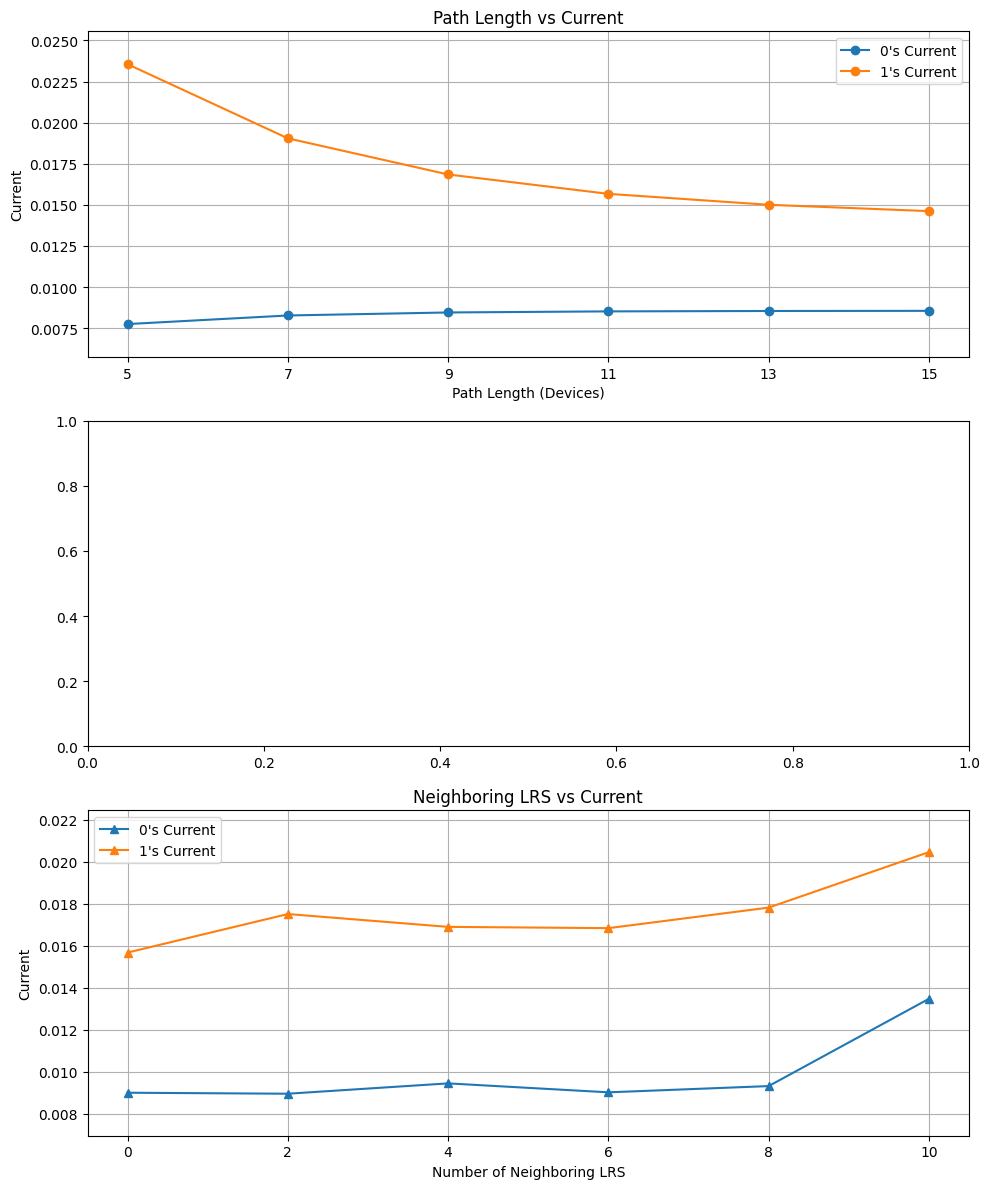

In [44]:
import matplotlib.pyplot as plt

# Data dictionaries
# PathLengthToCurrent = {
#     5: (0.007745385971938451, 0.023551863261134967),
#     7: (0.008267504893129014, 0.019043408743108878),
#     9: (0.008450833880855038, 0.016845443951959065),
#     11: (0.008516808400956706, 0.015666342235007676),
#     13: (0.008540778053806453, 0.015001275916004746),
#     15: (0.008549528971225863, 0.014615511186643807),
# }

# CrossbarSizeToCurrent = {
#     '32': (0.004660110793666563, 0.012468624217702591),
#     '64': (0.008516808400956706, 0.015666342235007676),
#     '128': (0.015069547971456362, 0.02140008135118546),
#     '256': (0.02587924787165762, 0.031173948270300997),
#     '512': (0.0432855033923527, 0.047223155999293755),
#     '1024': (0.07085383495114693, 0.07324924258531045),
# }

# NeighboringLrsToCurrent = {
#     0: (0.008516808400956706, 0.015666342235007676),
#     2: (0.008516808400956706, 0.017213563973001417),
#     4: (0.008516808400956706, 0.01724737837304309),
#     6: (0.008516808400956706, 0.021112137296648945),
#     8: (0.008516808400956706, 0.01820273187754229),
#     10: (0.008516808400956706, 0.018001589509635305),
# }

# Create individual plots with both v[0] (0's current) and v[1] (1's current)
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# 1. PathLengthToCurrent
x1 = list(PathLengthToCurrent.keys())
y1_0 = [v[0] for v in PathLengthToCurrent.values()]
y1_1 = [v[1] for v in PathLengthToCurrent.values()]
y1_min, y1_max = min(y1_0 + y1_1), max(y1_0 + y1_1)
axs[0].plot(x1, y1_0, marker='o', label="0's Current")
axs[0].plot(x1, y1_1, marker='o', label="1's Current")
axs[0].set_xticks(x1)
axs[0].set_title('Path Length vs Current')
axs[0].set_xlabel('Path Length (Devices)')
axs[0].set_ylabel('Current')
axs[0].set_ylim(y1_min - 0.002, y1_max + 0.002)
axs[0].legend()
axs[0].grid(True)

# # 2. CrossbarSizeToCurrent
# x2 = list(CrossbarSizeToCurrent.keys())
# y2_0 = [v[0] for v in CrossbarSizeToCurrent.values()]
# y2_1 = [v[1] for v in CrossbarSizeToCurrent.values()]
# y2_min, y2_max = min(y2_0 + y2_1), max(y2_0 + y2_1)
# axs[1].plot(x2, y2_0, marker='s', label="0's Current")
# axs[1].plot(x2, y2_1, marker='s', label="1's Current")
# axs[1].set_xticks(x2)
# axs[1].set_title('Crossbar Size vs Current')
# axs[1].set_xlabel('Crossbar Size')
# axs[1].set_ylabel('Current')
# axs[1].set_ylim(y2_min - 0.002, y2_max + 0.002)
# axs[1].legend()
# axs[1].grid(True)

# 3. NeighboringLrsToCurrent
x3 = list(NeighboringLrsToCurrent.keys())
y3_0 = [v[0] for v in NeighboringLrsToCurrent.values()]
y3_1 = [v[1] for v in NeighboringLrsToCurrent.values()]
y3_min, y3_max = min(y3_0 + y3_1), max(y3_0 + y3_1)
axs[2].plot(x3, y3_0, marker='^', label="0's Current")
axs[2].plot(x3, y3_1, marker='^', label="1's Current")
axs[2].set_xticks(x3)
axs[2].set_title('Neighboring LRS vs Current')
axs[2].set_xlabel('Number of Neighboring LRS')
axs[2].set_ylabel('Current')
axs[2].set_ylim(y3_min - 0.002, y3_max + 0.002)
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# tt_no = 10
# truth_tables_data = {}

# for i in range(1, tt_no + 1):
#     start_time = time.time()  # Record start
    
#     df, outputs = generate_adder_truth_table(i)
#     truth_tables_data[str(i)+'-bitAdder'] = {"outputs":outputs, "TruthTable_df":df}
    
#     print(f"Iteration {i} took {time.time() - start_time:.6f} seconds")

# # Save (pickle) to a file
# with open("Data/truth_tables_data.pkl", "wb") as f:
#     pickle.dump(truth_tables_data, f)

# print("written in truth_tables_data.pkl")

In [9]:
length_frequency = {}

for adderBit in Functional_Logic_Of_Path_Crossbar_Programings:
    for entry in Functional_Logic_Of_Path_Crossbar_Programings[adderBit]['AllIdealPathOfCurrent'].values():
        for key in entry:
            length = entry[key]['lengthOfDevices']
            if length in length_frequency:
                length_frequency[length] += 1
            else:
                length_frequency[length] = 1
    
    # Print frequency counts
    print("Frequency of LengthOfDevices values:")
    for length, count in length_frequency.items():
        print(f"Length {length}: {count} times")
    print()

Frequency of LengthOfDevices values:
Length 9: 6 times
Length 7: 2 times

Frequency of LengthOfDevices values:
Length 9: 22 times
Length 7: 10 times
Length 11: 12 times
Length 13: 12 times

Frequency of LengthOfDevices values:
Length 9: 86 times
Length 7: 42 times
Length 11: 92 times
Length 13: 44 times
Length 15: 24 times
Length 17: 24 times

Frequency of LengthOfDevices values:
Length 9: 342 times
Length 7: 170 times
Length 11: 540 times
Length 13: 172 times
Length 15: 184 times
Length 17: 88 times
Length 19: 48 times
Length 21: 48 times



In [47]:
# First import the module in a normal way:
import AnalogTestingOfPathCrossbar  

# Whenever you make changes in PathVerification.py (where PATH is defined),
# run these two lines to reload the module:
importlib.reload(AnalogTestingOfPathCrossbar)
from AnalogTestingOfPathCrossbar import AnalogTestingOfPathCrossbar

In [48]:
with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "rb") as f:
    Functional_Logic_Of_Path_Crossbar_Programings = pickle.load(f)
Functional_Logic_Of_Path_Crossbar_Programings_keys = list(Functional_Logic_Of_Path_Crossbar_Programings.keys())

Adder_guardbandsVsReistancesDetailsMaps_opt = {}

In [49]:
start = 0
iterations = 1

opt_min_One, opt_max_Zero = [], []
for i in range(start, len(Functional_Logic_Of_Path_Crossbar_Programings_keys)):
    adderName = Functional_Logic_Of_Path_Crossbar_Programings_keys[i]
    Functional_Logic_Of_Path_Crossbar_Programing_map = Functional_Logic_Of_Path_Crossbar_Programings[adderName]
    
    start_time = time.time()
    start_dt = datetime.datetime.fromtimestamp(start_time)

    n = len(Functional_Logic_Of_Path_Crossbar_Programing_map['Crossbar'])
    print(f"processing {adderName}. Crossbar dim.:{n}x{n} Started on {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
    Crossbar = Functional_Logic_Of_Path_Crossbar_Programing_map['Crossbar']
    Bitlines = Functional_Logic_Of_Path_Crossbar_Programing_map['Bitlines']
    TruthTable = Functional_Logic_Of_Path_Crossbar_Programing_map['TruthTable']
    OutputLine_Map = Functional_Logic_Of_Path_Crossbar_Programing_map['OutputLine_Map']
    SBDD_dimentions = Functional_Logic_Of_Path_Crossbar_Programing_map['SBDD (V x E)']
    AllIdealPathOfCurrent = Functional_Logic_Of_Path_Crossbar_Programing_map['AllIdealPathOfCurrent']
    CrossbarLongPaths = Functional_Logic_Of_Path_Crossbar_Programing_map['CrossbarLongPaths']
    End_Bitline_Output_Line = Functional_Logic_Of_Path_Crossbar_Programing_map['End_Bitline_Output_Line']

    print('len(Crossbar)',len(Crossbar))
    
    AnalogPathTest = AnalogTestingOfPathCrossbar(Crossbar=Crossbar, Bitlines=Bitlines, TruthTable=TruthTable, OutputLine_Map=OutputLine_Map, AllIdealPathOfCurrent=AllIdealPathOfCurrent, CrossbarLongPaths=CrossbarLongPaths, End_Bitline_Output_Line=End_Bitline_Output_Line)

    countMapBitlines = {}
    for _, bitline in enumerate(Bitlines):
        if(bitline not in countMapBitlines):
            countMapBitlines[bitline] = 0
        countMapBitlines[bitline]+=1
    # print('countMapBitlines',countMapBitlines)
    
    optimisation = True
    
    guardbandsVsReistancesMap = AnalogPathTest.Finding_optimal_HRS_using_binarysearch(high_variable_HRS=4e6, iterations=iterations, optimisation=optimisation)
    
    Adder_guardbandsVsReistancesDetailsMaps_opt[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']] = guardbandsVsReistancesMap

    opt_min_One.append(guardbandsVsReistancesMap['minOne'])
    opt_max_Zero.append(guardbandsVsReistancesMap['maxZero'])
    
    # Calculating average current passing thing through number of devices
    AdderNumDevicesToAvgCurrent_Map = {}
    for numOfDevices in AnalogPathTest.AdderNumDevicesToCurrents_Map.keys():
        AdderNumDevicesToAvgCurrent_Map[numOfDevices] = sum(AnalogPathTest.AdderNumDevicesToCurrents_Map[numOfDevices])/len(AnalogPathTest.AdderNumDevicesToCurrents_Map[numOfDevices])
    # print('AdderNumDevicesToAvgCurrent_Map',AdderNumDevicesToAvgCurrent_Map)
    Adder_guardbandsVsReistancesDetailsMaps_opt[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderNumDevicesToAvgCurrent_Map"] = AdderNumDevicesToAvgCurrent_Map
    Adder_guardbandsVsReistancesDetailsMaps_opt[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderNumDevicesToCurrents_Map"] = AnalogPathTest.AdderNumDevicesToCurrents_Map
    
    AdderFrequencyOfNumDevices = {}
    for entry in Functional_Logic_Of_Path_Crossbar_Programings[adderBit]['AllIdealPathOfCurrent'].values():
        for key in entry:
            length = entry[key]['lengthOfDevices']
            if length in AdderFrequencyOfNumDevices:
                AdderFrequencyOfNumDevices[length] += 1
            else:
                AdderFrequencyOfNumDevices[length] = 1
    Adder_guardbandsVsReistancesDetailsMaps_opt[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderFrequencyOfNumDevices"] = length_frequency

    #niti
    
    
    #Get duration of total time for all the iterations
    iteration_time = time.time() - start_time
    Adder_guardbandsVsReistancesDetailsMaps_opt[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["Duration"] = iteration_time
    print(f"{adderName} Enumeration Nodal analysis took {iteration_time:.6f} seconds")
    print('--------------------------------')
    print()
    if(i==5):
        break

# Save (pickle) to a file
with open("Data/Adder_guardbandsVsReistancesDetailsMaps_opt.pkl", "wb") as f:
    pickle.dump(Adder_guardbandsVsReistancesDetailsMaps_opt, f)

print("Data saved to Data/Adder_guardbandsVsReistancesDetailsMaps_opt.pkl")

processing 1-bitAdder. Crossbar dim.:64x64 Started on 2025-03-30 23:38:24
len(Crossbar) 64
resistance_value 2000000.0 0
end_cell (4, 11)
deactive_selector_lines1 {12}
row_i, col_j 4 0
children[(row_i,col_j)] [(1, 0), (4, 0)]
row_i, col_j 4 1
children[(row_i,col_j)] [(4, 1), (7, 1)]
deactive_selector_lines2 {12}
active_selector_lines {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13}
end_cell (8, 12)
deactive_selector_lines1 {11}
row_i, col_j 8 2
children[(row_i,col_j)] [(5, 2), (8, 2)]
row_i, col_j 8 3
children[(row_i,col_j)] [(6, 3), (8, 3)]
deactive_selector_lines2 {11}
active_selector_lines {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13}
guardBand 0.001204806507944611 Total Duration = 5.164e-2 sec
1-bitAdder Enumeration Nodal analysis took 0.056625 seconds
--------------------------------

processing 2-bitAdder. Crossbar dim.:64x64 Started on 2025-03-30 23:38:24
len(Crossbar) 64
resistance_value 2000000.0 0
end_cell (6, 23)
deactive_selector_lines1 {24, 25}
row_i, col_j 6 0
children[(row_i,col_j

In [13]:
with open("Data/Functional_Logic_Of_Path_Crossbar_Programings.pkl", "rb") as f:
    Functional_Logic_Of_Path_Crossbar_Programings = pickle.load(f)
Functional_Logic_Of_Path_Crossbar_Programings_keys = list(Functional_Logic_Of_Path_Crossbar_Programings.keys())

Adder_guardbandsVsReistancesDetailsMaps = {}

In [14]:
start = 0
iterations = 1

real_min_One, real_max_Zero = [], []
for i in range(start, len(Functional_Logic_Of_Path_Crossbar_Programings_keys)):
    adderName = Functional_Logic_Of_Path_Crossbar_Programings_keys[i]
    Functional_Logic_Of_Path_Crossbar_Programing_map = Functional_Logic_Of_Path_Crossbar_Programings[adderName]
    
    start_time = time.time()
    start_dt = datetime.datetime.fromtimestamp(start_time)

    n = len(Functional_Logic_Of_Path_Crossbar_Programing_map['Crossbar'])
    print(f"processing {adderName}. Crossbar dim.:{n}x{n} Started on {start_dt.strftime('%Y-%m-%d %H:%M:%S')}")
    Crossbar = Functional_Logic_Of_Path_Crossbar_Programing_map['Crossbar']
    Bitlines = Functional_Logic_Of_Path_Crossbar_Programing_map['Bitlines']
    TruthTable = Functional_Logic_Of_Path_Crossbar_Programing_map['TruthTable']
    OutputLine_Map = Functional_Logic_Of_Path_Crossbar_Programing_map['OutputLine_Map']
    SBDD_dimentions = Functional_Logic_Of_Path_Crossbar_Programing_map['SBDD (V x E)']
    AllIdealPathOfCurrent = Functional_Logic_Of_Path_Crossbar_Programing_map['AllIdealPathOfCurrent']
    CrossbarLongPaths = Functional_Logic_Of_Path_Crossbar_Programing_map['CrossbarLongPaths']
    End_Bitline_Output_Line = Functional_Logic_Of_Path_Crossbar_Programing_map['End_Bitline_Output_Line']

    print('len(Crossbar)',len(Crossbar))
    
    AnalogPathTest = AnalogTestingOfPathCrossbar(Crossbar=Crossbar, Bitlines=Bitlines, TruthTable=TruthTable, OutputLine_Map=OutputLine_Map, AllIdealPathOfCurrent=AllIdealPathOfCurrent, CrossbarLongPaths=CrossbarLongPaths, End_Bitline_Output_Line=End_Bitline_Output_Line)

    optimisation = False
    
    guardbandsVsReistancesMap = AnalogPathTest.Finding_optimal_HRS_using_binarysearch(high_variable_HRS=4e6, iterations=iterations, optimisation=optimisation)
    
    Adder_guardbandsVsReistancesDetailsMaps[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']] = guardbandsVsReistancesMap

    real_min_One.append(guardbandsVsReistancesMap['minOne'])
    real_max_Zero.append(guardbandsVsReistancesMap['maxZero'])
    
    # Calculating average current passing through number of devices
    AdderNumDevicesToAvgCurrent_Map = {}
    for numOfDevices in AnalogPathTest.AdderNumDevicesToCurrents_Map.keys():
        AdderNumDevicesToAvgCurrent_Map[numOfDevices] = sum(AnalogPathTest.AdderNumDevicesToCurrents_Map[numOfDevices])/len(AnalogPathTest.AdderNumDevicesToCurrents_Map[numOfDevices])
    # print('AdderNumDevicesToAvgCurrent_Map',AdderNumDevicesToAvgCurrent_Map)
    Adder_guardbandsVsReistancesDetailsMaps[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderNumDevicesToAvgCurrent_Map"] = AdderNumDevicesToAvgCurrent_Map
    Adder_guardbandsVsReistancesDetailsMaps[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderNumDevicesToCurrents_Map"] = AnalogPathTest.AdderNumDevicesToCurrents_Map
    
    AdderFrequencyOfNumDevices = {}
    for entry in Functional_Logic_Of_Path_Crossbar_Programings[adderBit]['AllIdealPathOfCurrent'].values():
        for key in entry:
            length = entry[key]['lengthOfDevices']
            if length in AdderFrequencyOfNumDevices:
                AdderFrequencyOfNumDevices[length] += 1
            else:
                AdderFrequencyOfNumDevices[length] = 1
    Adder_guardbandsVsReistancesDetailsMaps[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["AdderFrequencyOfNumDevices"] = length_frequency

    
    
    #Get duration of total time for all the iterations
    iteration_time = time.time() - start_time
    Adder_guardbandsVsReistancesDetailsMaps[Functional_Logic_Of_Path_Crossbar_Programing_map['AdderBit']]["Duration"] = iteration_time
    print(f"{adderName} Enumeration Nodal analysis took {iteration_time:.6f} seconds")
    print('--------------------------------')
    print()
    if(i==5):
        break

# Save (pickle) to a file
with open("Data/Adder_guardbandsVsReistancesDetailsMaps.pkl", "wb") as f:
    pickle.dump(Adder_guardbandsVsReistancesDetailsMaps, f)

print("Data saved to Data/Adder_guardbandsVsReistancesDetailsMaps.pkl")

processing 1-bitAdder. Crossbar dim.:64x64 Started on 2025-03-30 20:11:50
len(Crossbar) 64
resistance_value 2000000.0 0
input_assignment {'a0': 0, 'b0': 0, 'cin': 0} outputSelectorLine 11
selectorLinesActive {1, 2, 5, 6, 9, 11, 13}
input_assignment {'a0': 0, 'b0': 0, 'cin': 0} outputSelectorLine 12
selectorLinesActive {1, 2, 5, 6, 9, 12, 13}
Duration: 3.45e-2 sec
000000 sum0 0.007566386533472945
000000 cout 0.00716410864968381
input_assignment {'a0': 0, 'b0': 0, 'cin': 1} outputSelectorLine 11
selectorLinesActive {1, 2, 5, 6, 10, 11, 13}
input_assignment {'a0': 0, 'b0': 0, 'cin': 1} outputSelectorLine 12
selectorLinesActive {1, 2, 5, 6, 10, 12, 13}
Duration: 3.209e-2 sec
111111 sum0 0.014213907123159697
000000 cout 0.008202170002462237
input_assignment {'a0': 0, 'b0': 1, 'cin': 0} outputSelectorLine 11
selectorLinesActive {1, 2, 4, 7, 8, 9, 11, 13}
input_assignment {'a0': 0, 'b0': 1, 'cin': 0} outputSelectorLine 12
selectorLinesActive {1, 2, 4, 7, 8, 9, 12, 13}
Duration: 3.586e-2 sec
1

In [50]:
print('real_min_One',real_min_One)
print('opt_min_One',opt_min_One)
print()
print('real_max_Zero',real_max_Zero)
print('opt_max_Zero',opt_max_Zero)

real_min_One [np.float64(0.014187935725829931), np.float64(0.01392713300850214), np.float64(0.014827878262041674), np.float64(0.01608355241721403)]
opt_min_One [np.float64(0.014085409589858345), np.float64(0.011829501557207378), np.float64(0.011014702122041097), np.float64(0.010751125283359652)]

real_max_Zero [np.float64(0.010877285441602633), np.float64(0.01472054943878368), np.float64(0.016898964722076384), np.float64(0.018692896325514744)]
opt_max_Zero [np.float64(0.012880603081913734), np.float64(0.015973572327996045), np.float64(0.01797872409369657), np.float64(0.019630887613004612)]


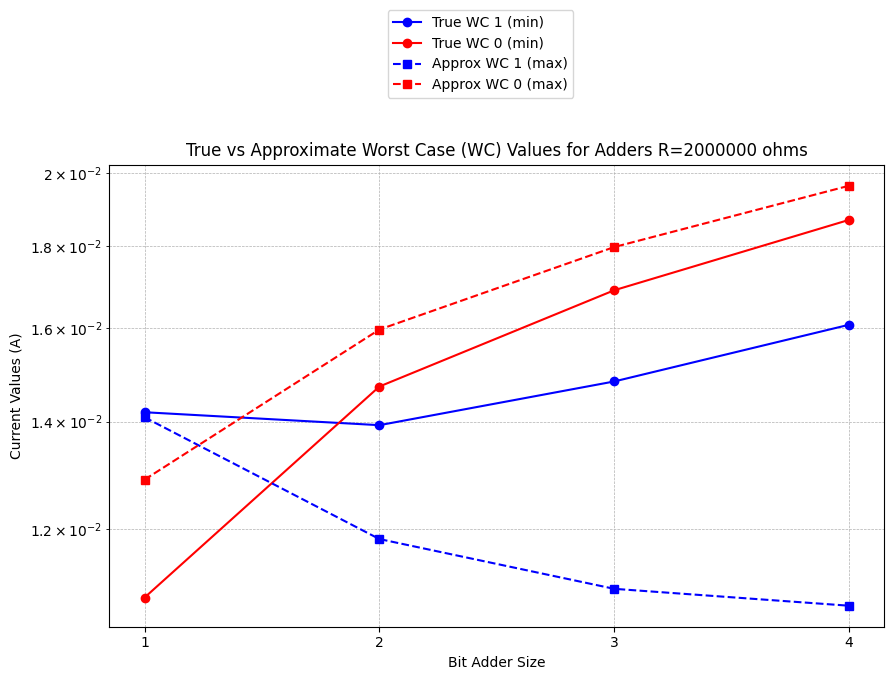

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data extraction from log text
bit_sizes = [i+1 for i in range(len(real_min_One))]

# True values
true_min_ones_currents = real_min_One
true_max_zeros_currents = real_max_Zero

# Approx values (same as true values in provided log)
approx_min_ones_currents = opt_min_One
approx_max_zeros_currents = opt_max_Zero

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(bit_sizes, true_min_ones_currents, 'bo-', label='True WC 1 (min)')
plt.plot(bit_sizes, true_max_zeros_currents, 'ro-', label='True WC 0 (min)')

plt.plot(bit_sizes, approx_min_ones_currents, 'bs--', label='Approx WC 1 (max)')
plt.plot(bit_sizes, approx_max_zeros_currents, 'rs--', label='Approx WC 0 (max)')

plt.xlabel('Bit Adder Size')
plt.ylabel('Current Values (A)')
plt.yscale('log')  # Log scale for better visualization
plt.title('True vs Approximate Worst Case (WC) Values for Adders R=2000000 ohms')
# Placing legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(0.35, 1.35))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Force x-ticks to be each integer from 1 through the maximum bit size
plt.xticks(range(1, len(bit_sizes) + 1))

# Show plot
plt.show()

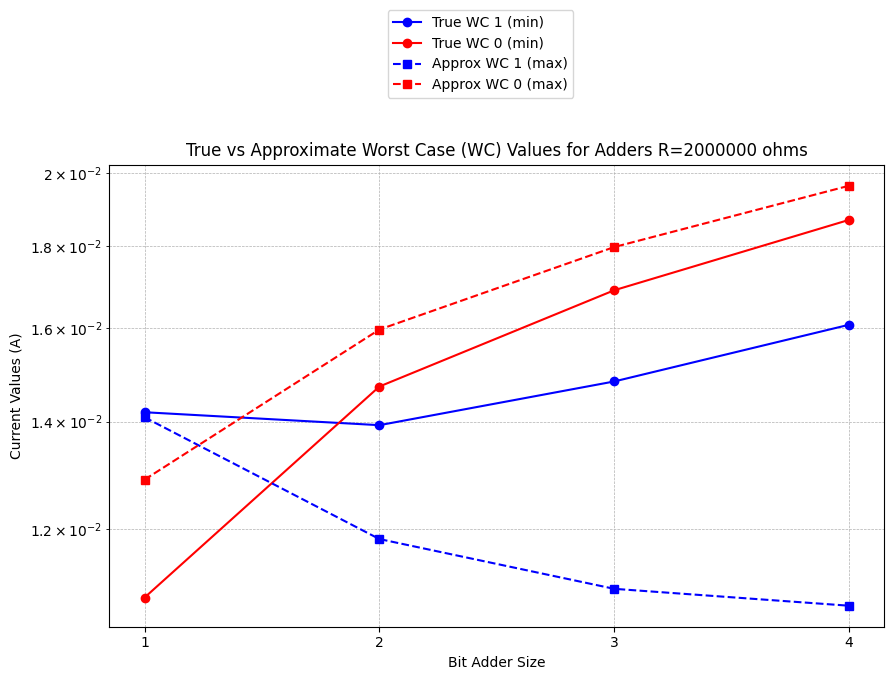

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data extraction from log text
bit_sizes = [i+1 for i in range(len(real_min_One))]

# True values
true_min_ones_currents = real_min_One
true_max_zeros_currents = real_max_Zero

# Approx values (same as true values in provided log)
approx_min_ones_currents = opt_min_One
approx_max_zeros_currents = opt_max_Zero

# Plotting
plt.figure(figsize=(10, 6))

plt.plot(bit_sizes, true_min_ones_currents, 'bo-', label='True WC 1 (min)')
plt.plot(bit_sizes, true_max_zeros_currents, 'ro-', label='True WC 0 (min)')

plt.plot(bit_sizes, approx_min_ones_currents, 'bs--', label='Approx WC 1 (max)')
plt.plot(bit_sizes, approx_max_zeros_currents, 'rs--', label='Approx WC 0 (max)')

plt.xlabel('Bit Adder Size')
plt.ylabel('Current Values (A)')
plt.yscale('log')  # Log scale for better visualization
plt.title('True vs Approximate Worst Case (WC) Values for Adders R=2000000 ohms')
# Placing legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(0.35, 1.35))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Force x-ticks to be each integer from 1 through the maximum bit size
plt.xticks(range(1, len(bit_sizes) + 1))

# Show plot
plt.show()

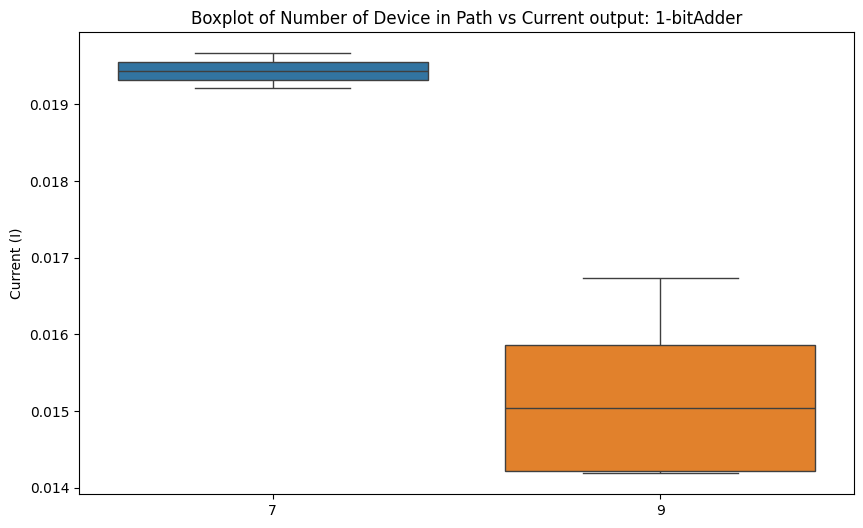

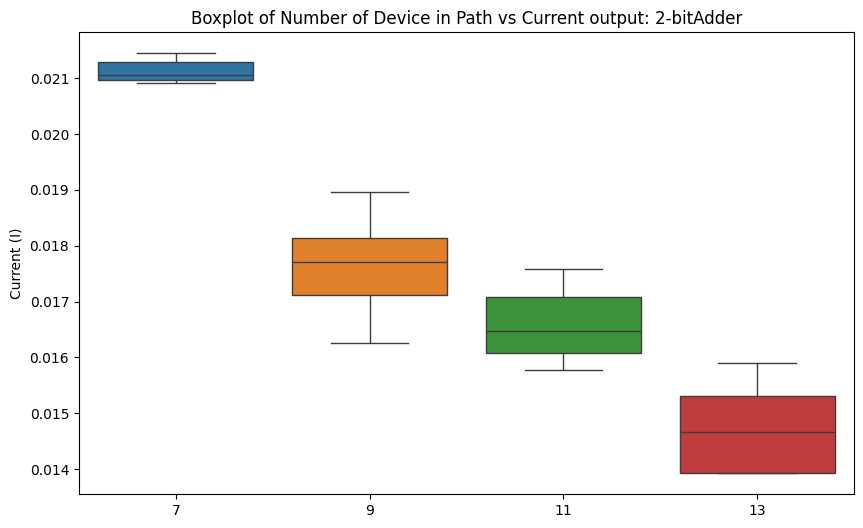

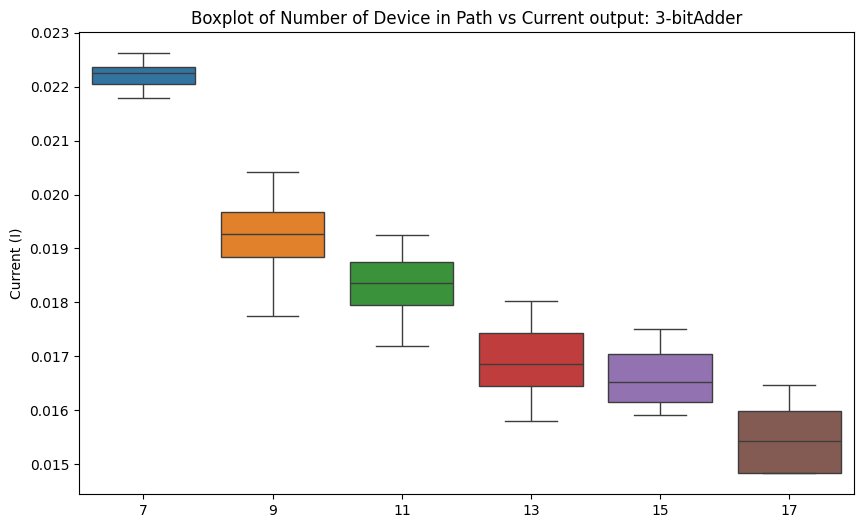

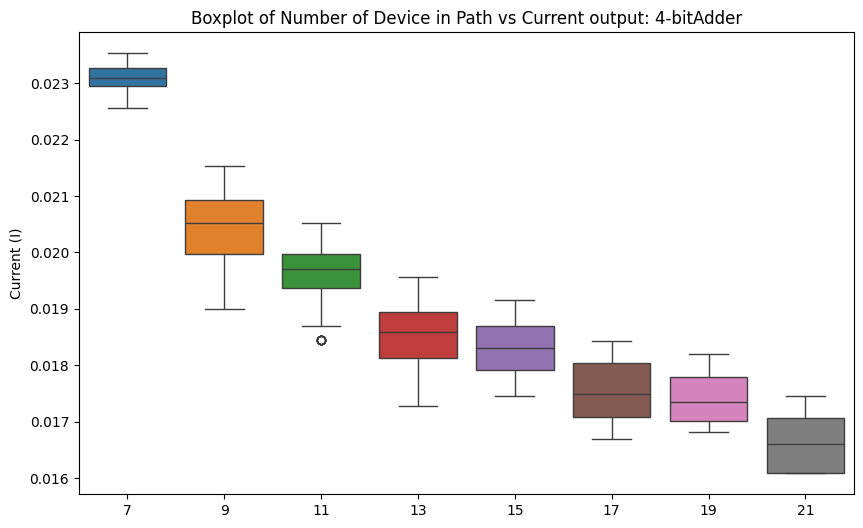

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_boxplot_from_sorted_hashmap(data_map, adderBit, sort_keys=True):
    """
    Plots a boxplot (quartile graph) from a hashmap where:
    - Keys are labels for the boxplot.
    - Values are lists of values to be plotted.
    - Sorts the keys before plotting if sort_keys is True.
    """
    # Sort the dictionary by keys if required
    if sort_keys:
        data_map = dict(sorted(data_map.items()))

    # Extract sorted labels and corresponding data
    labels = list(data_map.keys())
    data = list(data_map.values())

    # Create the boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data)
    
    # Set labels
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
    plt.ylabel("Current (I)")
    plt.title("Boxplot of Number of Device in Path vs Current output: "+adderBit)

    # Show the plot
    plt.show()

for adderBit in Adder_guardbandsVsReistancesDetailsMaps:
    plot_boxplot_from_sorted_hashmap(Adder_guardbandsVsReistancesDetailsMaps[adderBit]['AdderNumDevicesToCurrents_Map'], adderBit)

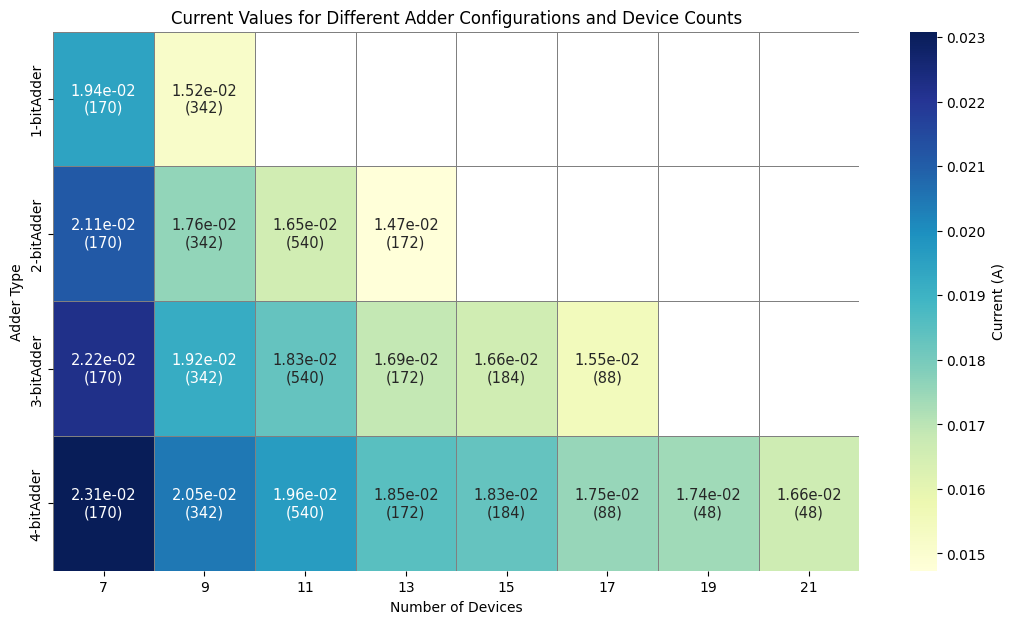

In [52]:
# Extract unique adders and device counts
adders = list(Adder_guardbandsVsReistancesDetailsMaps.keys())
devices = sorted({device for adder in adders for device in Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map'].keys()})

# Create a DataFrame to hold the current values
data = pd.DataFrame(index=adders, columns=devices, dtype=float)

# Create an annotation matrix for the heatmap text
annot_matrix = data.astype(str)

# Populate the DataFrame with current values and create annotation text
for adder in adders:
    for device in devices:
        if device in Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map']:
            current = Adder_guardbandsVsReistancesDetailsMaps[adder]['AdderNumDevicesToAvgCurrent_Map'][device]
            freqDevices = Adder_guardbandsVsReistancesDetailsMaps[adder]["AdderFrequencyOfNumDevices"][device]

            data.loc[adder, device] = current

            # Formatting annotation with scientific notation for current and frequency on the next line
            annot_matrix.loc[adder, device] = f"{current:.2e}\n({freqDevices})"
        else:
            annot_matrix.loc[adder, device] = ""


# Plotting the heatmap
plt.figure(figsize=(13, 7))
ax = sns.heatmap(data, annot=annot_matrix.values, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Current (A)'},
                 linewidths=0.5, linecolor='gray', annot_kws={"fontsize": 10.5})  # Adjust font size here

# Set labels and title
plt.xlabel('Number of Devices')
plt.ylabel('Adder Type')
plt.title('Current Values for Different Adder Configurations and Device Counts')

# Show the plot
plt.show()

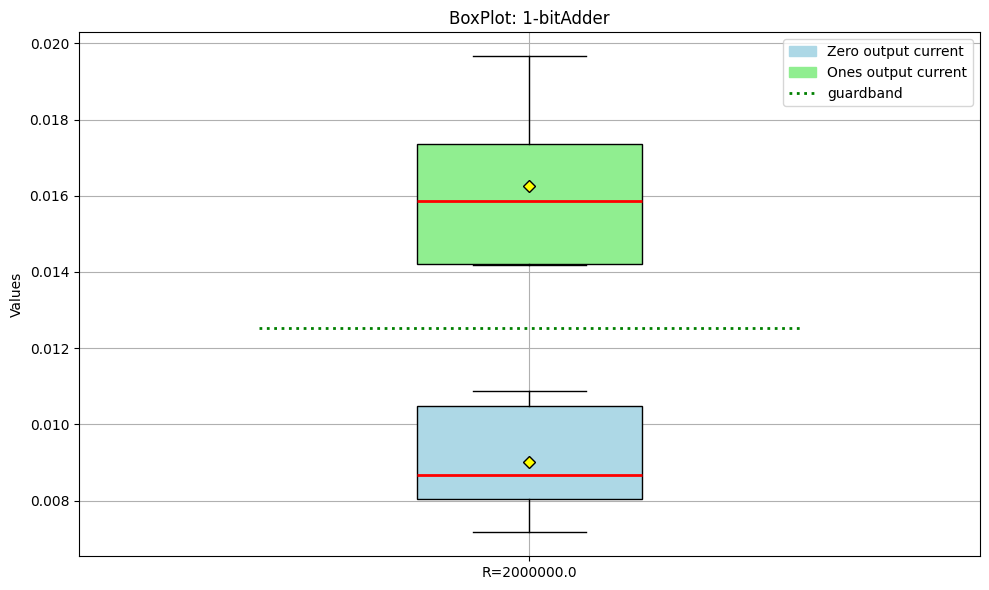

In [104]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines


with open("Data/Adder_guardbandsVsReistancesDetailsMaps.pkl", "rb") as f:
    Adder_guardbandsVsReistancesDetailsMaps = pickle.load(f)

Adder_guardbandsVsReistancesDetailsMaps_keys = list(Adder_guardbandsVsReistancesDetailsMaps.keys())
for i in range(len(Adder_guardbandsVsReistancesDetailsMaps_keys)):
    key_adder = Adder_guardbandsVsReistancesDetailsMaps_keys[i]
    Adder_guardbandsVsReistancesDetailsMap = Adder_guardbandsVsReistancesDetailsMaps[key_adder]

    dataZeros = []
    dataOnes = []
    group_labels = []
    
    # Positions for each group
    pos = []
    guardband_values = []

    len_record_details = len(Adder_guardbandsVsReistancesDetailsMap["guardbands"])
    
    for j in range(len_record_details):
        dataZeros.append(Adder_guardbandsVsReistancesDetailsMap["zerosCurrents_lst"][j])
        dataOnes.append(Adder_guardbandsVsReistancesDetailsMap["onesCurrents_lst"][j])
        group_labels.append("R="+str(Adder_guardbandsVsReistancesDetailsMap["resistance_values"][j]))

        guardband_values.append(max(Adder_guardbandsVsReistancesDetailsMap["zerosCurrents_lst"][j])+(Adder_guardbandsVsReistancesDetailsMap["guardbands"][j]/2))
    
        pos.append(j+1)

    if(pos):

        plt.figure(figsize=(10, 6))
    
        
        # Plot dataZeros
        bp_zeros = plt.boxplot(
            dataZeros, 
            positions=pos, 
            patch_artist=True, 
            widths=0.25,             # Adjust width as desired
            showmeans=True,          
            boxprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow')
        )
        
        # Color the boxes (dataZeros)
        for patch in bp_zeros['boxes']:
            patch.set_facecolor('lightblue')
        
        # Plot dataOnes
        bp_ones = plt.boxplot(
            dataOnes, 
            positions=pos, 
            patch_artist=True, 
            widths=0.25,
            showmeans=True,
            boxprops=dict(color='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='red', linewidth=2),
            meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='yellow')
        )
    
        # Add green dotted lines based on each group's guardband value
        for j, guardband_value in enumerate(guardband_values):
            # We'll draw a short line around x_val (from x_val-0.3 to x_val+0.3):
            plt.hlines(
                y=guardband_value,
                xmin=pos[j]-0.3,
                xmax=pos[j]+0.3,
                colors='green',
                linestyles='dotted',
                linewidth=2
            )
        
        # Color the boxes (dataOnes)
        for patch in bp_ones['boxes']:
            patch.set_facecolor('lightgreen')
        
        # Move x-ticks to the midpoint between the two boxplots of each group
        plt.xticks(pos, group_labels)
        
        plt.ylabel("Values")
        plt.title("BoxPlot: "+key_adder)
        plt.grid(True)
        
        # Create legend elements
        zero_patch = mpatches.Patch(color='lightblue', label='Zero output current')
        one_patch = mpatches.Patch(color='lightgreen', label='Ones output current')
        guardband_line = mlines.Line2D([], [], color='green', linestyle='dotted', linewidth=2, label='guardband')
    
        plt.legend(handles=[zero_patch, one_patch, guardband_line], loc='upper right')
        
        plt.tight_layout()
        plt.show()

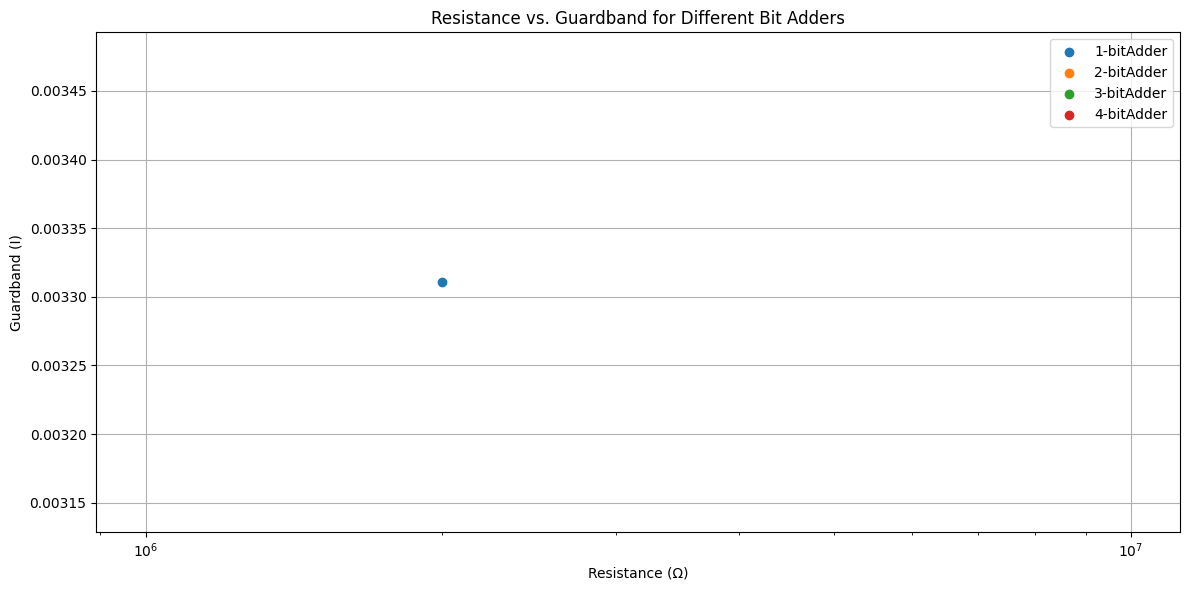

In [105]:
with open("Data/Adder_guardbandsVsReistancesDetailsMaps.pkl", "rb") as f:
    Adder_guardbandsVsReistancesDetailsMaps = pickle.load(f)

plt.figure(figsize=(12, 6))

# A color map or predefined list of colors can be used if you have multiple adders
# For example: colors = plt.cm.tab10(np.linspace(0, 1, len(Adder_guardbandsVsReistancesDetailsMaps)))
# But often letting matplotlib handle defaults is fine.

for i, (adder_name, data) in enumerate(Adder_guardbandsVsReistancesDetailsMaps.items()):
    guardbands = data['guardbands']
    resistances = data['resistance_values']

    
    # Plot them (resistance on x-axis, guardband on y-axis)
    # marker='o' to see points, linestyle='-' to connect them
    plt.scatter(
        resistances, guardbands, 
        marker='o', 
        label=adder_name
    )

plt.xscale('log')  # Often helpful if resistance spans large orders of magnitude
plt.xlabel('Resistance (Ω)')
plt.ylabel('Guardband (I)')
plt.title('Resistance vs. Guardband for Different Bit Adders')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [106]:
# Suppose you have the following lists (all of the same length)
AdderBit = ["1-Bit Adder", "2-Bit Adder", "3-Bit Adder", "4-Bit Adder", "5-Bit Adder"]
SBDDSize = ['13 x 9', '26 x 18', '39 x 27', '52 x 36', '131 x 76']
CrossbarSize = [16, 32, 64, 64, 256]
NumberOfBooleanPermutations = [2, 4, 6, 8, 10]
NumberOfBooleanIterations = [2**2, 2**4, 2**6, 2**8, 2**10]
TimeForEachIterations = [1.5, 8.5, 50, 110, 410]
TotalTimeForEachIterations = [NumberOfBooleanIterations[i]*TimeForEachIterations[i] for i in range(len(NumberOfBooleanIterations))]
TotalTimeInHours = [TotalTimeForEachIterations[i]/3600 for i in range(len(TotalTimeForEachIterations))]
# Put them into a dictionary where each key is the column name,
# and each value is one of the lists:
data = {
    "AdderBit": AdderBit,
    "SBDDSize (V x E)": SBDDSize,
    "CrossbarSize >max(V, E)": CrossbarSize,
    "Number of boolean inputs (n)":NumberOfBooleanPermutations,
    "Total Input permuatations (2^n)":NumberOfBooleanIterations,
    "Time for each boolean input (t)":TimeForEachIterations,
    "Total Time For all boolean inputs ....... T = (t x 2^n)": TotalTimeForEachIterations,
    "Total Time In Hours For Single Binary search iterations of resitance Thr = (T/3600) hours": TotalTimeInHours,
    "Total Iterations (ThrX10) time": [i*10 for i in TotalTimeInHours]
}

# Convert the dictionary into a pandas DataFrame
df = pd.DataFrame(data)

df

,AdderBit,SBDDSize (V x E),"CrossbarSize >max(V, E)",Number of boolean inputs (n),Total Input permuatations (2^n),Time for each boolean input (t),Total Time For all boolean inputs ....... T = (t x 2^n),Total Time In Hours For Single Binary search iterations of resitance Thr = (T/3600) hours,Total Iterations (ThrX10) time
0,1-Bit Adder,13 x 9,16,2,4,1.5,6.0,0.001667,0.016667
1,2-Bit Adder,26 x 18,32,4,16,8.5,136.0,0.037778,0.377778
2,3-Bit Adder,39 x 27,64,6,64,50.0,3200.0,0.888889,8.888889
3,4-Bit Adder,52 x 36,64,8,256,110.0,28160.0,7.822222,78.222222
4,5-Bit Adder,131 x 76,256,10,1024,410.0,419840.0,116.622222,1166.222222


In [64]:
import numpy as np
import time
import scipy.sparse as sp
import scipy.sparse.linalg as spla

def check_matrix_sparsity_and_efficiency(A, b=None, sparsity_threshold=0.3):
    """
    Checks if a given 2D NumPy matrix A is sparse, based on the ratio of non-zeros.
    If b is given, also compare the runtime of dense vs. sparse solvers.

    Parameters
    ----------
    A : np.matrix or np.ndarray
        The matrix of interest.
    b : np.ndarray or list or None, optional
        The RHS vector for testing linear solving.
        If None, no solver timing is performed.
    sparsity_threshold : float
        If non_zero_ratio < sparsity_threshold, we classify the matrix as "sparse".

    Returns
    -------
    None
    """

    # Ensure A is a NumPy array
    A_arr = np.array(A, dtype=float)  # convert np.matrix to np.ndarray if needed

    print("Matrix dimentions (m x m):", A_arr.shape)
    
    # 1) Check the sparsity ratio
    total_elements = A_arr.size
    nonzero_elements = np.count_nonzero(A_arr)
    nonzero_ratio = nonzero_elements / total_elements
    zero_ratio = 1.0 - nonzero_ratio

    print("=== Sparsity Check ===")
    print(f"Matrix shape: {A_arr.shape}")
    print(f"Total elements: {total_elements}")
    print(f"Non-zero elements: {nonzero_elements}")
    print(f"Non-zero ratio: {nonzero_ratio:.2f}  ({nonzero_ratio*100:.2f} %)")
    print(f"Zero ratio: {zero_ratio:.2f}        ({zero_ratio*100:.2f} %)")

    if nonzero_ratio < sparsity_threshold:
        print("Matrix is considered SPARSE based on the given threshold.")
    else:
        print("Matrix is NOT considered sparse based on the given threshold.")

    # 2) (Optional) Compare efficiency of dense vs. sparse solver
    if b is not None:
        print("\n=== Solver Efficiency Check ===")
        
        # Ensure b is a 1D array
        b_arr = np.array(b, dtype=float).ravel()

        # Dense solve timing
        start_time = time.time()
        x_dense = np.linalg.solve(A_arr, b_arr)
        dense_time = time.time() - start_time

        # Sparse solve timing
        A_csr = sp.csr_matrix(A_arr)
        start_time = time.time()
        x_sparse = spla.spsolve(A_csr, b_arr)
        sparse_time = time.time() - start_time

        print(f"Dense solve time  : {dense_time:.6f} seconds")
        print(f"Sparse solve time : {sparse_time:.6f} seconds")

        # (Optional) Compare solutions
        diff = np.linalg.norm(x_dense - x_sparse, ord=2)
        print(f"Difference between dense and sparse solutions: {diff:.2e}")

    print("\nDone.\n")


# ======================
# Example usage:
# ======================
if __name__ == "__main__":
    # Example 1: A small "sparse" matrix
    A_example_1 = AnalogPathTest.tempMatrix[0]
    b_example_1 = AnalogPathTest.tempMatrix[1]

    check_matrix_sparsity_and_efficiency(A_example_1, b_example_1, sparsity_threshold=0.2)

Matrix dimentions (m x m): (128, 128)
=== Sparsity Check ===
Matrix shape: (128, 128)
Total elements: 16384
Non-zero elements: 8256
Non-zero ratio: 0.50  (50.39 %)
Zero ratio: 0.50        (49.61 %)
Matrix is NOT considered sparse based on the given threshold.

=== Solver Efficiency Check ===
Dense solve time  : 0.000000 seconds
Sparse solve time : 0.001999 seconds
Difference between dense and sparse solutions: 8.72e-15

Done.

